# Data Frame Combination

## Price volume data (basic df)

Load the raw price-volume dataset, standardize the date field, convert the status flag to numeric, and check which columns contain missing values.

In [68]:
import pandas as pd 
import numpy as np
prices = pd.read_parquet("data/prices.parquet")
prices["date"] = pd.to_datetime(prices["date"]).dt.normalize()
prices["status"] = pd.to_numeric(prices["status"], errors="coerce")
prices.isna().sum()


ticker                 0
instrument_id          0
date                   0
open                   0
high                   0
low                    0
close                  0
adjusted_close         0
volume                 0
market_cap        185103
status                 0
updated                0
dtype: int64

### Status Flag Checks

Check the distribution of the status flag to understand how many active and inactive records appear in the raw data.

In [69]:
prices["status"].value_counts(dropna=False)

status
1    7930541
0      69827
Name: count, dtype: int64

Find all duplicated stock-date rows and inspect their status values. This helps confirm whether duplicates are mainly caused by status-0 records.

In [70]:
dup_mask = prices.duplicated(
    subset=["instrument_id", "date"],
    keep=False
)

dup_rows = prices.loc[dup_mask].copy()

dup_rows["status"].value_counts(dropna=False)

status
1    153022
0     69827
Name: count, dtype: int64

Verify whether every status-0 row belongs to a duplicated stock-date group. If this count is zero, status-0 rows do not add unique observations.

In [71]:
status0 = prices[prices["status"].eq(0)].copy()

status0_not_dup = status0[
    ~status0.set_index(["instrument_id", "date"]).index.isin(
        prices[prices.duplicated(["instrument_id", "date"], keep=False)]
        .set_index(["instrument_id", "date"])
        .index
    )
]

len(status0_not_dup)

0

### Duplicate Row Cleaning

Display examples of duplicated stock-date rows so we can compare the records before deciding how to clean them.

In [72]:
dup_mask_clean = prices.duplicated(
    subset=["instrument_id", "date"],
    keep=False
)

dup_rows_clean = (
    prices
    .loc[dup_mask_clean]
    .sort_values(["instrument_id", "date", "ticker"])
)

dup_rows_clean.head(10)

,ticker,instrument_id,date,open,high,low,close,adjusted_close,volume,market_cap,status,updated
62,PARA,99,2000-01-03,1.8965,1.8965,1.7774,1.7793,2.2412,1762300.0,9.939995e+08,0,2025-11-04 11:20:12
61,PSKY,99,2000-01-03,1.8965,1.8965,1.7774,1.7793,2.2412,1762300.0,9.939995e+08,1,2025-11-04 20:40:50
985,PARA,99,2000-01-04,1.7657,1.7715,1.6758,1.6778,2.1133,1871300.0,9.372969e+08,0,2025-11-04 11:20:12
984,PSKY,99,2000-01-04,1.7657,1.7715,1.6758,1.6778,2.1133,1871300.0,9.372969e+08,1,2025-11-04 20:40:50
1903,PARA,99,2000-01-05,1.6817,1.6895,1.5938,1.6036,2.0198,2265200.0,8.958453e+08,0,2025-11-04 11:20:12
1902,PSKY,99,2000-01-05,1.6817,1.6895,1.5938,1.6036,2.0198,2265200.0,8.958453e+08,1,2025-11-04 20:40:50
2827,PARA,99,2000-01-06,1.5938,1.6055,1.5547,1.5977,2.0125,3235500.0,8.925493e+08,0,2025-11-04 11:20:12
2826,PSKY,99,2000-01-06,1.5938,1.6055,1.5547,1.5977,2.0125,3235500.0,8.925493e+08,1,2025-11-04 20:40:50
3748,PARA,99,2000-01-07,1.5938,1.6915,1.5860,1.6915,2.1306,2464800.0,9.449504e+08,0,2025-11-04 11:20:12
3747,PSKY,99,2000-01-07,1.5938,1.6915,1.5860,1.6915,2.1306,2464800.0,9.449504e+08,1,2025-11-04 20:40:50


Compare duplicate rows column by column and identify which fields have conflicting values within the same stock-date key.

In [73]:
key_cols = ["instrument_id", "date"]

non_key_cols = [c for c in dup_rows_clean.columns if c not in key_cols]

nunique_by_group = (
    dup_rows_clean
    .groupby(key_cols)[non_key_cols]
    .nunique(dropna=False)
)

cols_with_conflict = nunique_by_group.columns[
    (nunique_by_group > 1).any()
].tolist()

cols_with_conflict

['ticker', 'status', 'updated']

Most columns are consistent within each duplicated stock-date group. The conflicting columns listed above are the fields that need special attention before dropping duplicates.

Remove duplicated stock-date rows by keeping the record with the highest status value, confirm that each key is now unique, and drop the unused update timestamp.

In [74]:
dup_before = prices.duplicated(subset=["instrument_id", "date"], keep=False).sum()
print("Duplicated instrument_id-date rows before cleaning:", dup_before)

prices_clean = (
    prices
    .sort_values(
        ["instrument_id", "date", "status"],
        ascending=[True, True, False]
    )
    .drop_duplicates(
        subset=["instrument_id", "date"],
        keep="first"
    )
    .copy()
)


max_rows_per_stock_date = (
    prices_clean
    .groupby(["instrument_id", "date"])
    .size()
    .max()
)

print("Max rows per instrument_id-date after cleaning:", max_rows_per_stock_date)

prices_clean = prices_clean.drop(columns='updated').copy()

prices_clean

Duplicated instrument_id-date rows before cleaning: 222849
Max rows per instrument_id-date after cleaning: 1


,ticker,instrument_id,date,open,high,low,close,adjusted_close,volume,market_cap,status
3846661,HLT,1,2013-12-12,21.2969,21.9168,21.2469,21.4968,41.6951,23716568.0,2.116608e+10,1
3847967,HLT,1,2013-12-13,21.9868,22.3767,21.5468,22.0967,42.8587,3984417.0,2.175675e+10,1
3849273,HLT,1,2013-12-16,23.1266,25.9462,21.5168,21.5168,41.7339,3226908.0,2.118577e+10,1
3850578,HLT,1,2013-12-17,21.6068,21.9868,21.5768,21.8068,42.2963,1584449.0,2.147131e+10,1
3851884,HLT,1,2013-12-18,21.8268,22.1767,21.6568,21.8268,42.3351,1955194.0,2.149100e+10,1
...,...,...,...,...,...,...,...,...,...,...,...
7993852,DBD,1612,2024-12-24,43.2500,43.8300,42.8800,43.6100,43.6100,49800.0,1.638719e+09,1
7995479,DBD,1612,2024-12-26,42.9700,43.6000,42.6800,43.5600,43.5600,95500.0,1.636840e+09,1
7997108,DBD,1612,2024-12-27,43.3100,43.5300,41.9500,42.9400,42.9400,94400.0,1.613543e+09,1
7998737,DBD,1612,2024-12-30,42.7300,43.1200,41.7750,42.7900,42.7900,70900.0,1.607906e+09,1


### Price Adjustment Factor

Compute the adjustment factor from adjusted close divided by raw close. This factor is used to make the other OHLC prices comparable across corporate actions.

In [75]:
prices_clean = prices_clean.sort_values(["instrument_id", "date"]).copy()

prices_clean["adj_factor"] = (
    prices_clean["adjusted_close"] / prices_clean["close"]
)

Apply the adjustment factor to open, high, and low prices so all OHLC fields are on the same adjusted scale as adjusted close.

In [76]:
# Adjust OHLC
prices_clean["adjusted_open"] = prices_clean["open"] * prices_clean["adj_factor"]
prices_clean["adjusted_high"] = prices_clean["high"] * prices_clean["adj_factor"]
prices_clean["adjusted_low"] = prices_clean["low"] * prices_clean["adj_factor"]
prices_clean

,ticker,instrument_id,date,open,high,low,close,adjusted_close,volume,market_cap,status,adj_factor,adjusted_open,adjusted_high,adjusted_low
3846661,HLT,1,2013-12-12,21.2969,21.9168,21.2469,21.4968,41.6951,23716568.0,2.116608e+10,1,1.939596,41.307375,42.509730,41.210395
3847967,HLT,1,2013-12-13,21.9868,22.3767,21.5468,22.0967,42.8587,3984417.0,2.175675e+10,1,1.939597,42.645538,43.401787,41.792115
3849273,HLT,1,2013-12-16,23.1266,25.9462,21.5168,21.5168,41.7339,3226908.0,2.118577e+10,1,1.939596,44.856262,50.325147,41.733900
3850578,HLT,1,2013-12-17,21.6068,21.9868,21.5768,21.8068,42.2963,1584449.0,2.147131e+10,1,1.939592,41.908382,42.645427,41.850194
3851884,HLT,1,2013-12-18,21.8268,22.1767,21.6568,21.8268,42.3351,1955194.0,2.149100e+10,1,1.939593,42.335100,43.013763,42.005369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7993852,DBD,1612,2024-12-24,43.2500,43.8300,42.8800,43.6100,43.6100,49800.0,1.638719e+09,1,1.000000,43.250000,43.830000,42.880000
7995479,DBD,1612,2024-12-26,42.9700,43.6000,42.6800,43.5600,43.5600,95500.0,1.636840e+09,1,1.000000,42.970000,43.600000,42.680000
7997108,DBD,1612,2024-12-27,43.3100,43.5300,41.9500,42.9400,42.9400,94400.0,1.613543e+09,1,1.000000,43.310000,43.530000,41.950000
7998737,DBD,1612,2024-12-30,42.7300,43.1200,41.7750,42.7900,42.7900,70900.0,1.607906e+09,1,1.000000,42.730000,43.120000,41.775000


### Return Targets

Build adjusted return targets for the next tradable period. Cross-day returns use adjusted prices so splits and dividends do not distort the target.

In [77]:
prices_clean = prices_clean.sort_values(["instrument_id", "date"]).copy()

# Adjusted returns
prices_clean["target_c2o_next_adj"] = (
    prices_clean.groupby("instrument_id")["adjusted_open"].shift(-2)
    / prices_clean.groupby("instrument_id")["adjusted_close"].shift(-1)
    - 1
)

# 明日 open -> 明日 close
prices_clean["target_o2c_next_adj"] = (
    prices_clean.groupby("instrument_id")["adjusted_close"].shift(-1)
    / prices_clean.groupby("instrument_id")["adjusted_open"].shift(-1)
    - 1
)

# 今日 close -> 明日 close
prices_clean["target_c2c_adj"] = (
    prices_clean.groupby("instrument_id")["adjusted_close"].shift(-1)
    / prices_clean["adjusted_close"]
    - 1
)


# Drop rows without targets
target_cols = [
    "target_c2o_next_adj",
    "target_o2c_next_adj",
    "target_c2c_adj",
]

# prices_clean = prices_clean[
#     prices_clean[target_cols].notna().all(axis=1)
# ].copy()

prices_clean

,ticker,instrument_id,date,open,high,low,close,adjusted_close,volume,market_cap,status,adj_factor,adjusted_open,adjusted_high,adjusted_low,target_c2o_next_adj,target_o2c_next_adj,target_c2c_adj
3846661,HLT,1,2013-12-12,21.2969,21.9168,21.2469,21.4968,41.6951,23716568.0,2.116608e+10,1,1.939596,41.307375,42.509730,41.210395,0.046608,0.004998,0.027907
3847967,HLT,1,2013-12-13,21.9868,22.3767,21.5468,22.0967,42.8587,3984417.0,2.175675e+10,1,1.939597,42.645538,43.401787,41.792115,0.004181,-0.069608,-0.026244
3849273,HLT,1,2013-12-16,23.1266,25.9462,21.5168,21.5168,41.7339,3226908.0,2.118577e+10,1,1.939596,44.856262,50.325147,41.733900,0.000917,0.009256,0.013476
3850578,HLT,1,2013-12-17,21.6068,21.9868,21.5768,21.8068,42.2963,1584449.0,2.147131e+10,1,1.939592,41.908382,42.645427,41.850194,-0.003663,0.000000,0.000917
3851884,HLT,1,2013-12-18,21.8268,22.1767,21.6568,21.8268,42.3351,1955194.0,2.149100e+10,1,1.939593,42.335100,43.013763,42.005369,0.009873,0.024367,0.020614
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7993852,DBD,1612,2024-12-24,43.2500,43.8300,42.8800,43.6100,43.6100,49800.0,1.638719e+09,1,1.000000,43.250000,43.830000,42.880000,-0.005739,0.013731,-0.001147
7995479,DBD,1612,2024-12-26,42.9700,43.6000,42.6800,43.5600,43.5600,95500.0,1.636840e+09,1,1.000000,42.970000,43.600000,42.680000,-0.004891,-0.008543,-0.014233
7997108,DBD,1612,2024-12-27,43.3100,43.5300,41.9500,42.9400,42.9400,94400.0,1.613543e+09,1,1.000000,43.310000,43.530000,41.950000,0.006544,0.001404,-0.003493
7998737,DBD,1612,2024-12-30,42.7300,43.1200,41.7750,42.7900,42.7900,70900.0,1.607906e+09,1,1.000000,42.730000,43.120000,41.775000,NaN,-0.000697,0.005842


Check the remaining missing values after cleaning and target construction.

In [78]:
prices_clean.isna().sum()

ticker                      0
instrument_id               0
date                        0
open                        0
high                        0
low                         0
close                       0
adjusted_close              0
volume                      0
market_cap             179649
status                      0
adj_factor                  0
adjusted_open               0
adjusted_high               0
adjusted_low                0
target_c2o_next_adj      3212
target_o2c_next_adj      1607
target_c2c_adj           1607
dtype: int64

## cheapness_scores / gics_info

Load the cheapness score dataset and the static GICS mapping table. Normalize the date column so it can be merged with the daily price-volume panel.

In [79]:
cheapness_scores = pd.read_parquet("data/cheapness_scores.parquet")
cheapness_scores['date'] = pd.to_datetime(cheapness_scores['date']).dt.normalize()

gics_info = pd.read_parquet("data/gics_info.parquet")
cheapness_scores.isna().sum()

instrument_id               0
date                        0
ticker                      0
gics_sector           2258868
gics_group            2258868
gics_industry         2258868
gics_subindustry      2258868
adjusted_close              0
market_cap                  0
valuation_score       2264928
quality_score         2259182
health_score          2263078
momentum_score        2261827
final_score           2270090
final_score_clean     2293111
score_velocity        2271681
score_acceleration    2273272
regime_break                0
value_trap                  0
dtype: int64

Check whether cheapness_scores has duplicated instrument-date keys, and identify which columns have conflicting values inside those duplicate groups.

In [80]:
key_cols = ["instrument_id", "date"]

dup = cheapness_scores[
    cheapness_scores.duplicated(subset=key_cols, keep=False)
].copy()

non_key_cols = [c for c in cheapness_scores.columns if c not in key_cols]

dup_diff_summary = (
    dup
    .groupby(key_cols)[non_key_cols]
    .nunique(dropna=False)
)

cols_with_conflict = dup_diff_summary.columns[
    (dup_diff_summary > 1).any()
].tolist()

cols_with_conflict

['ticker', 'score_velocity', 'score_acceleration', 'regime_break']

Some duplicated instrument-date rows differ only in ticker, score velocity, score acceleration, or regime break. These conflict columns are removed later because the core cheapness scores remain usable.

Merge cheapness scores into the cleaned price-volume dataframe, combine duplicate market cap and adjusted close columns, drop unstable conflict fields, and forward-fill market cap within each stock.

In [81]:
df = prices_clean.merge(
    cheapness_scores,
    how="left",
    left_on=["ticker", "instrument_id", "date"],
    right_on=["ticker", "instrument_id", "date"],
    validate="m:1",
)

df["market_cap"] = df["market_cap_x"].combine_first(df["market_cap_y"])
df["adjusted_close"] = df["adjusted_close_x"].combine_first(df["adjusted_close_y"])
df = df.drop(columns=["market_cap_x", "market_cap_y", "adjusted_close_x", "adjusted_close_y", 'score_velocity', 'score_acceleration', 'regime_break'])
df[['market_cap']] = (
    df
    .groupby("instrument_id")[['market_cap']]
    .ffill()
)
df

,ticker,instrument_id,date,open,high,low,close,volume,status,adj_factor,...,gics_subindustry,valuation_score,quality_score,health_score,momentum_score,final_score,final_score_clean,value_trap,market_cap,adjusted_close
0,HLT,1,2013-12-12,21.2969,21.9168,21.2469,21.4968,23716568.0,1,1.939596,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,2.116608e+10,41.6951
1,HLT,1,2013-12-13,21.9868,22.3767,21.5468,22.0967,3984417.0,1,1.939597,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,2.175675e+10,42.8587
2,HLT,1,2013-12-16,23.1266,25.9462,21.5168,21.5168,3226908.0,1,1.939596,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,2.118577e+10,41.7339
3,HLT,1,2013-12-17,21.6068,21.9868,21.5768,21.8068,1584449.0,1,1.939592,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,2.147131e+10,42.2963
4,HLT,1,2013-12-18,21.8268,22.1767,21.6568,21.8268,1955194.0,1,1.939593,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,2.149100e+10,42.3351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7883225,DBD,1612,2024-12-24,43.2500,43.8300,42.8800,43.6100,49800.0,1,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.638719e+09,43.6100
7883226,DBD,1612,2024-12-26,42.9700,43.6000,42.6800,43.5600,95500.0,1,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.636840e+09,43.5600
7883227,DBD,1612,2024-12-27,43.3100,43.5300,41.9500,42.9400,94400.0,1,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.613543e+09,42.9400
7883228,DBD,1612,2024-12-30,42.7300,43.1200,41.7750,42.7900,70900.0,1,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.607906e+09,42.7900


### GICS Mapping

Treat GICS information as a static stock-level classification. Deduplicate the mapping table, replace any old GICS columns in df, merge the clean classifications by instrument_id, and check remaining missing values.

In [82]:
# 使用 gics_info 靜態資料，補回 df 的 GICS 產業分類
# df 原本的 GICS 欄位名稱
old_gics_cols = ["gics_sector", "gics_group", "gics_industry", "gics_subindustry"]

# gics_info 裡面的 GICS 欄位名稱
gics_info_cols = ["sector", "industry_group", "industry", "subindustry"]

# 我們希望最後 df 裡面統一使用的欄位名稱
gics_rename_map = {
    "sector": "gics_sector",
    "industry_group": "gics_group",
    "industry": "gics_industry",
    "subindustry": "gics_subindustry",
}

#  gics_info 是靜態 mapping table，理論上一檔股票只能有一組 GICS
dup_gics = gics_info[gics_info.duplicated(subset=["instrument_id"], keep=False)]
print("Number of duplicated instrument_id in gics_info:", dup_gics["instrument_id"].nunique())

# 如果有重複，先保留最後一筆；正常情況應該不會有
gics_info_clean = (
    gics_info
    .drop_duplicates(subset=["instrument_id"], keep="last")
    [["instrument_id"] + gics_info_cols]
    .rename(columns=gics_rename_map)
)

# 刪掉 df 原本的 GICS 欄位
cols_to_drop = [col for col in old_gics_cols if col in df.columns]

df = df.drop(columns=cols_to_drop)
df = df.merge(
    gics_info_clean,
    on="instrument_id",
    how="left",
    validate="m:1",
)

print("Missing GICS after merging gics_info:")
print(df[old_gics_cols].isna().sum())

df

Number of duplicated instrument_id in gics_info: 0
Missing GICS after merging gics_info:
gics_sector         0
gics_group          0
gics_industry       0
gics_subindustry    0
dtype: int64


,ticker,instrument_id,date,open,high,low,close,volume,status,adj_factor,...,momentum_score,final_score,final_score_clean,value_trap,market_cap,adjusted_close,gics_sector,gics_group,gics_industry,gics_subindustry
0,HLT,1,2013-12-12,21.2969,21.9168,21.2469,21.4968,23716568.0,1,1.939596,...,NaN,NaN,NaN,False,2.116608e+10,41.6951,25,2530,253010,25301020
1,HLT,1,2013-12-13,21.9868,22.3767,21.5468,22.0967,3984417.0,1,1.939597,...,NaN,NaN,NaN,False,2.175675e+10,42.8587,25,2530,253010,25301020
2,HLT,1,2013-12-16,23.1266,25.9462,21.5168,21.5168,3226908.0,1,1.939596,...,NaN,NaN,NaN,False,2.118577e+10,41.7339,25,2530,253010,25301020
3,HLT,1,2013-12-17,21.6068,21.9868,21.5768,21.8068,1584449.0,1,1.939592,...,NaN,NaN,NaN,False,2.147131e+10,42.2963,25,2530,253010,25301020
4,HLT,1,2013-12-18,21.8268,22.1767,21.6568,21.8268,1955194.0,1,1.939593,...,NaN,NaN,NaN,False,2.149100e+10,42.3351,25,2530,253010,25301020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7883225,DBD,1612,2024-12-24,43.2500,43.8300,42.8800,43.6100,49800.0,1,1.000000,...,NaN,NaN,NaN,NaN,1.638719e+09,43.6100,45,4520,452020,45202030
7883226,DBD,1612,2024-12-26,42.9700,43.6000,42.6800,43.5600,95500.0,1,1.000000,...,NaN,NaN,NaN,NaN,1.636840e+09,43.5600,45,4520,452020,45202030
7883227,DBD,1612,2024-12-27,43.3100,43.5300,41.9500,42.9400,94400.0,1,1.000000,...,NaN,NaN,NaN,NaN,1.613543e+09,42.9400,45,4520,452020,45202030
7883228,DBD,1612,2024-12-30,42.7300,43.1200,41.7750,42.7900,70900.0,1,1.000000,...,NaN,NaN,NaN,NaN,1.607906e+09,42.7900,45,4520,452020,45202030


## Earnings Data

Load the earnings calendar and transformed earnings features. Check missing announcement fields before deciding how to align earnings information to the trading timeline.

In [83]:
earnings_calendar = pd.read_parquet("data/earnings_calendar.parquet")
earnings_transfo = pd.read_parquet("data/earnings_transfo.parquet")


# The target return is measured from t+1 close to t+2 open.

print(sum(earnings_calendar['reporting_date'].isna()))
print(sum(earnings_calendar['reporting_time'].isna()))
print(sum(earnings_calendar['before_after_market'].isna()))

# reporting_time is available for all rows.
# Fill missing before_after_market values using the 15:50 cutoff from the coursework instructions.
# after-market announcements are treated as available on the reporting date.
# before-market announcements are shifted to the previous trading date.

earnings_calendar[earnings_calendar['before_after_market'].isna()]


0
0
823


,stock_id,reporting_date,strat_trading_date,reporting_time,before_after_market,period,period_end_date
137,4,2016-11-17,NaT,0 days 14:30:00,None,FY2017Q3,2016-10-29
155,4,2021-05-27,NaT,0 days 13:30:00,None,FY2022Q1,2021-05-01
194,5,2020-02-27,NaT,0 days 13:49:00,None,FY2019Q4,2019-12-31
262,6,2022-08-01,NaT,0 days 18:32:27,None,FY2022Q2,2022-06-30
326,7,2024-10-23,NaT,0 days 13:30:00,None,FY2024Q3,2024-09-30
...,...,...,...,...,...,...,...
60453,1588,2024-02-21,NaT,0 days 15:39:00,None,FY2023Q4,2023-12-30
60454,1588,2024-04-17,NaT,0 days 14:17:00,None,FY2024Q1,2024-03-30
60455,1588,2024-07-17,NaT,0 days 15:12:00,None,FY2024Q2,2024-06-29
60456,1588,2024-10-16,NaT,0 days 15:23:00,None,FY2024Q3,2024-09-28


### Calendar Alignment

Normalize earnings dates, infer missing before/after-market labels using a 15:50 cutoff, merge the timing flag into earnings features, and then merge earnings data into the main dataframe.

In [84]:
earnings_transfo["date"] = pd.to_datetime(
    earnings_transfo["date"]
).dt.normalize()

earnings_calendar["reporting_date"] = pd.to_datetime(
    earnings_calendar["reporting_date"]
).dt.normalize()

# Fill missing before_after_market using 15:50 cutoff
cutoff = pd.Timedelta(hours=15, minutes=50)

mask_missing = earnings_calendar["before_after_market"].isna()

earnings_calendar.loc[mask_missing, "before_after_market"] = np.where(
    earnings_calendar.loc[mask_missing, "reporting_time"] < cutoff,
    "before",
    "after",
)

#  Merge before/after flag onto earnings_transfo
earnings_aligned = earnings_transfo.merge(
    earnings_calendar[['stock_id', 'reporting_date', 'before_after_market']],
    how="left",
    left_on=["stock_id", "date"],
    right_on=["stock_id", "reporting_date"],
    validate="m:1",
).drop(columns='reporting_date')

df = df.merge(
    earnings_aligned,
    how="left",
    left_on=["instrument_id", "date"],
    right_on=["stock_id", "date"],
    validate="m:1"
    ).drop(columns='stock_id')
df

,ticker,instrument_id,date,open,high,low,close,volume,status,adj_factor,...,repsf4,sue,inesp,inesn,reps41,repsfs,repsfl,nspc5,deps,before_after_market
0,HLT,1,2013-12-12,21.2969,21.9168,21.2469,21.4968,23716568.0,1,1.939596,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HLT,1,2013-12-13,21.9868,22.3767,21.5468,22.0967,3984417.0,1,1.939597,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,HLT,1,2013-12-16,23.1266,25.9462,21.5168,21.5168,3226908.0,1,1.939596,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,HLT,1,2013-12-17,21.6068,21.9868,21.5768,21.8068,1584449.0,1,1.939592,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,HLT,1,2013-12-18,21.8268,22.1767,21.6568,21.8268,1955194.0,1,1.939593,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7883225,DBD,1612,2024-12-24,43.2500,43.8300,42.8800,43.6100,49800.0,1,1.000000,...,NaN,NaN,1.0,0.0,NaN,-0.003897,-0.025200,0.05,0.00103,NaN
7883226,DBD,1612,2024-12-26,42.9700,43.6000,42.6800,43.5600,95500.0,1,1.000000,...,NaN,NaN,1.0,0.0,NaN,-0.003869,-0.025172,0.05,0.00103,NaN
7883227,DBD,1612,2024-12-27,43.3100,43.5300,41.9500,42.9400,94400.0,1,1.000000,...,NaN,NaN,1.0,0.0,NaN,-0.003520,-0.024823,0.05,0.00103,NaN
7883228,DBD,1612,2024-12-30,42.7300,43.1200,41.7750,42.7900,70900.0,1,1.000000,...,NaN,NaN,1.0,0.0,NaN,-0.003433,-0.024736,0.05,0.00103,NaN


### Before vs After Market Timing

Create the previous trading date for each stock. This is needed because before-market announcements can be known before the previous row's target trade is formed.

In [85]:
# Build stock-level previous trading date
stock_dates = (
    df[["instrument_id", "date"]]
    .drop_duplicates()
    .sort_values(["instrument_id", "date"])
)

stock_dates["prev_date"] = (
    stock_dates.groupby("instrument_id")["date"].shift(1)
)

df = df.merge(
    stock_dates[["instrument_id", "date", "prev_date"]],
    how="left",
    on=["instrument_id", "date"],
    validate="m:1",
)

df

,ticker,instrument_id,date,open,high,low,close,volume,status,adj_factor,...,sue,inesp,inesn,reps41,repsfs,repsfl,nspc5,deps,before_after_market,prev_date
0,HLT,1,2013-12-12,21.2969,21.9168,21.2469,21.4968,23716568.0,1,1.939596,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
1,HLT,1,2013-12-13,21.9868,22.3767,21.5468,22.0967,3984417.0,1,1.939597,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013-12-12
2,HLT,1,2013-12-16,23.1266,25.9462,21.5168,21.5168,3226908.0,1,1.939596,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013-12-13
3,HLT,1,2013-12-17,21.6068,21.9868,21.5768,21.8068,1584449.0,1,1.939592,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013-12-16
4,HLT,1,2013-12-18,21.8268,22.1767,21.6568,21.8268,1955194.0,1,1.939593,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013-12-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7883225,DBD,1612,2024-12-24,43.2500,43.8300,42.8800,43.6100,49800.0,1,1.000000,...,NaN,1.0,0.0,NaN,-0.003897,-0.025200,0.05,0.00103,NaN,2024-12-23
7883226,DBD,1612,2024-12-26,42.9700,43.6000,42.6800,43.5600,95500.0,1,1.000000,...,NaN,1.0,0.0,NaN,-0.003869,-0.025172,0.05,0.00103,NaN,2024-12-24
7883227,DBD,1612,2024-12-27,43.3100,43.5300,41.9500,42.9400,94400.0,1,1.000000,...,NaN,1.0,0.0,NaN,-0.003520,-0.024823,0.05,0.00103,NaN,2024-12-26
7883228,DBD,1612,2024-12-30,42.7300,43.1200,41.7750,42.7900,70900.0,1,1.000000,...,NaN,1.0,0.0,NaN,-0.003433,-0.024736,0.05,0.00103,NaN,2024-12-27


Inspect one stock around an earnings period to verify the raw earnings features, timing flag, and previous trading date alignment.

In [86]:
df[df['instrument_id']==1612][-40:-34][['instrument_id', 'date'] + ['epsp', 'epsf', 'reps1', 'repsf4', 'sue', 'inesp',
       'inesn', 'reps41', 'repsfs', 'repsfl', 'nspc5', 'deps',
       'before_after_market', 'prev_date']]


,instrument_id,date,epsp,epsf,reps1,repsf4,sue,inesp,inesn,reps41,repsfs,repsfl,nspc5,deps,before_after_market,prev_date
7883190,1612,2024-11-04,NaN,0.024283,NaN,NaN,NaN,0.0,1.0,NaN,-0.007163,-0.018199,0.00,0.00112,NaN,2024-11-01
7883191,1612,2024-11-05,NaN,0.023590,NaN,NaN,NaN,0.0,1.0,NaN,-0.007857,-0.018892,0.00,0.00112,NaN,2024-11-04
7883192,1612,2024-11-06,NaN,0.022843,NaN,NaN,NaN,0.0,1.0,NaN,-0.008604,-0.019639,0.00,0.00112,NaN,2024-11-05
7883193,1612,2024-11-07,0.012779,0.028101,-0.015339,-0.171313,-0.621133,0.0,1.0,-0.139207,0.000000,-0.021303,0.00,-0.01003,before,2024-11-06
7883194,1612,2024-11-08,NaN,0.025713,NaN,NaN,NaN,1.0,0.0,NaN,-0.002388,-0.023691,0.05,0.00103,NaN,2024-11-07
7883195,1612,2024-11-11,NaN,0.026179,NaN,NaN,NaN,1.0,0.0,NaN,-0.001922,-0.023225,0.05,0.00103,NaN,2024-11-08


Copy selected before-market earnings features to the previous trading date, filling only missing values so existing observations are not overwritten.

In [87]:
# Define columns to copy from before-market event to previous date
copy_cols = [
    "epsp",
    "reps1",
    "repsf4",
    "sue",
    "reps41",
]
# -----------------------------
# 7. Extract before-market rows and move their features to prev_date
# -----------------------------
before_mask = (
    df["before_after_market"].eq("before")
    & df["prev_date"].notna()
)

before_to_prev = df.loc[
    before_mask,
    ["instrument_id", "prev_date"] + copy_cols
].copy()

# prev_date becomes the date to be updated
before_to_prev = before_to_prev.rename(columns={"prev_date": "date"})

# If multiple before events map to same stock-date, keep last
before_to_prev = before_to_prev.drop_duplicates(
    subset=["instrument_id", "date"],
    keep="last",
)

# -----------------------------
# 8. Merge moved values back to original table
# -----------------------------
df = df.merge(
    before_to_prev,
    how="left",
    on=["instrument_id", "date"],
    suffixes=("", "_from_before"),
    validate="m:1",
)

# -----------------------------
# 9. Fill only NaN values using copied before-market features
# -----------------------------
for col in copy_cols:
    moved_col = col + "_from_before"
    if moved_col in df.columns:
        df[col] = df[col].combine_first(
            df[moved_col]
        )
        df = df.drop(columns=moved_col)

df

,ticker,instrument_id,date,open,high,low,close,volume,status,adj_factor,...,sue,inesp,inesn,reps41,repsfs,repsfl,nspc5,deps,before_after_market,prev_date
0,HLT,1,2013-12-12,21.2969,21.9168,21.2469,21.4968,23716568.0,1,1.939596,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
1,HLT,1,2013-12-13,21.9868,22.3767,21.5468,22.0967,3984417.0,1,1.939597,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013-12-12
2,HLT,1,2013-12-16,23.1266,25.9462,21.5168,21.5168,3226908.0,1,1.939596,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013-12-13
3,HLT,1,2013-12-17,21.6068,21.9868,21.5768,21.8068,1584449.0,1,1.939592,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013-12-16
4,HLT,1,2013-12-18,21.8268,22.1767,21.6568,21.8268,1955194.0,1,1.939593,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013-12-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7883225,DBD,1612,2024-12-24,43.2500,43.8300,42.8800,43.6100,49800.0,1,1.000000,...,NaN,1.0,0.0,NaN,-0.003897,-0.025200,0.05,0.00103,NaN,2024-12-23
7883226,DBD,1612,2024-12-26,42.9700,43.6000,42.6800,43.5600,95500.0,1,1.000000,...,NaN,1.0,0.0,NaN,-0.003869,-0.025172,0.05,0.00103,NaN,2024-12-24
7883227,DBD,1612,2024-12-27,43.3100,43.5300,41.9500,42.9400,94400.0,1,1.000000,...,NaN,1.0,0.0,NaN,-0.003520,-0.024823,0.05,0.00103,NaN,2024-12-26
7883228,DBD,1612,2024-12-30,42.7300,43.1200,41.7750,42.7900,70900.0,1,1.000000,...,NaN,1.0,0.0,NaN,-0.003433,-0.024736,0.05,0.00103,NaN,2024-12-27


Create an effective earnings date: before-market announcements use the previous trading date, while after-market announcements stay on the reporting date.

In [88]:
df = df.sort_values(["instrument_id", "date"]).copy()

# initialize
df["earn_effective_date"] = pd.NaT

# before-market: move effective date to previous trading date
mask_before = (
    df["before_after_market"].eq("before")
    & df["prev_date"].notna()
)

df.loc[mask_before, "earn_effective_date"] = df.loc[
    mask_before, "prev_date"
]

# after-market: effective date stays on reporting date
mask_after = df["before_after_market"].eq("after")

df.loc[mask_after, "earn_effective_date"] = df.loc[
    mask_after, "date"
]

df["earn_effective_date"] = pd.to_datetime(df["earn_effective_date"])

Build an earnings-event window around each effective earnings date and flag rows whose trade date falls within that window.

In [89]:
# row t is implemented at close of t+1
df["trade_date"] = df.groupby("instrument_id")["date"].shift(-1)

earn_events = (
    df.loc[df["earn_effective_date"].notna(), ["instrument_id", "earn_effective_date"]]
    .drop_duplicates()
)

window_rows = []

for offset in [0]:
    tmp = earn_events.copy()
    tmp["trade_date"] = tmp.groupby("instrument_id")["earn_effective_date"].transform(
        lambda x: x
    )
    tmp["trade_date"] = tmp["earn_effective_date"] + pd.offsets.BDay(offset)
    window_rows.append(tmp[["instrument_id", "trade_date"]])

earn_window = pd.concat(window_rows, ignore_index=True).drop_duplicates()
earn_window["in_earn_window"] = True

df = df.merge(
    earn_window,
    how="left",
    on=["instrument_id", "trade_date"],
    validate="m:1",
)

df["in_earn_window"] = df["in_earn_window"].fillna(False)

/var/folders/yb/8ggp9gv52cb8_8xlnpwq7qz40000gn/T/ipykernel_69621/3697890830.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["in_earn_window"] = df["in_earn_window"].fillna(False)


Check the same example stock after moving before-market features to confirm that the selected values now appear on the intended previous date.

In [90]:
# Check that before-market values were copied to the previous reporting-date row where needed.

df[df['before_after_market']=="before"]
df[df['instrument_id']==1612][-40:-34][['instrument_id', 'date', 'before_after_market'] + copy_cols]


,instrument_id,date,before_after_market,epsp,reps1,repsf4,sue,reps41
7883190,1612,2024-11-04,NaN,NaN,NaN,NaN,NaN,NaN
7883191,1612,2024-11-05,NaN,NaN,NaN,NaN,NaN,NaN
7883192,1612,2024-11-06,NaN,0.012779,-0.015339,-0.171313,-0.621133,-0.139207
7883193,1612,2024-11-07,before,0.012779,-0.015339,-0.171313,-0.621133,-0.139207
7883194,1612,2024-11-08,NaN,NaN,NaN,NaN,NaN,NaN
7883195,1612,2024-11-11,NaN,NaN,NaN,NaN,NaN,NaN


### Forward Fill

Forward-fill earnings and analyst-revision features within each stock. This carries the latest known earnings information forward without using future data.

In [91]:
# Forward-fill earnings features.
# Assumptions:
# 1. before-market earnings have already been copied to the previous trading date.
# 2. after-market earnings remain on the reporting date.
# 3. Only forward-filling is allowed; no backward fill is used.

df = df.sort_values(["instrument_id", "date"]).copy()

# These earnings and analyst-revision features can be carried forward.
earn_feature_cols = [
    "epsp",
    "epsf",
    "reps1",
    "repsf4",
    "sue",
    "inesp",
    "inesn",
    "reps41",
    "repsfs",
    "repsfl",
    "nspc5",
    "deps",
]

# Forward-fill within each stock in date order.
df[earn_feature_cols] = (
    df
    .groupby("instrument_id")[earn_feature_cols]
    .ffill()
)

df

,ticker,instrument_id,date,open,high,low,close,volume,status,adj_factor,...,reps41,repsfs,repsfl,nspc5,deps,before_after_market,prev_date,earn_effective_date,trade_date,in_earn_window
0,HLT,1,2013-12-12,21.2969,21.9168,21.2469,21.4968,23716568.0,1,1.939596,...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,2013-12-13,False
1,HLT,1,2013-12-13,21.9868,22.3767,21.5468,22.0967,3984417.0,1,1.939597,...,NaN,NaN,NaN,NaN,NaN,NaN,2013-12-12,NaT,2013-12-16,False
2,HLT,1,2013-12-16,23.1266,25.9462,21.5168,21.5168,3226908.0,1,1.939596,...,NaN,NaN,NaN,NaN,NaN,NaN,2013-12-13,NaT,2013-12-17,False
3,HLT,1,2013-12-17,21.6068,21.9868,21.5768,21.8068,1584449.0,1,1.939592,...,NaN,NaN,NaN,NaN,NaN,NaN,2013-12-16,NaT,2013-12-18,False
4,HLT,1,2013-12-18,21.8268,22.1767,21.6568,21.8268,1955194.0,1,1.939593,...,NaN,NaN,NaN,NaN,NaN,NaN,2013-12-17,NaT,2013-12-19,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7883225,DBD,1612,2024-12-24,43.2500,43.8300,42.8800,43.6100,49800.0,1,1.000000,...,-0.139207,-0.003897,-0.025200,0.05,0.00103,NaN,2024-12-23,NaT,2024-12-26,False
7883226,DBD,1612,2024-12-26,42.9700,43.6000,42.6800,43.5600,95500.0,1,1.000000,...,-0.139207,-0.003869,-0.025172,0.05,0.00103,NaN,2024-12-24,NaT,2024-12-27,False
7883227,DBD,1612,2024-12-27,43.3100,43.5300,41.9500,42.9400,94400.0,1,1.000000,...,-0.139207,-0.003520,-0.024823,0.05,0.00103,NaN,2024-12-26,NaT,2024-12-30,False
7883228,DBD,1612,2024-12-30,42.7300,43.1200,41.7750,42.7900,70900.0,1,1.000000,...,-0.139207,-0.003433,-0.024736,0.05,0.00103,NaN,2024-12-27,NaT,2024-12-31,False


Inspect the example stock after forward filling to confirm that earnings features persist correctly across later dates.

In [92]:
# Check that before-market values were copied to the previous reporting-date row where needed.

df[df['before_after_market']=="before"]
df[df['instrument_id']==1612][-40:-34][['instrument_id', 'date', 'before_after_market'] + earn_feature_cols]


,instrument_id,date,before_after_market,epsp,epsf,reps1,repsf4,sue,inesp,inesn,reps41,repsfs,repsfl,nspc5,deps
7883190,1612,2024-11-04,NaN,0.028117,0.024283,-0.006355,NaN,0.044249,0.0,1.0,-0.000290,-0.007163,-0.018199,0.00,0.00112
7883191,1612,2024-11-05,NaN,0.028117,0.023590,-0.006355,NaN,0.044249,0.0,1.0,-0.000290,-0.007857,-0.018892,0.00,0.00112
7883192,1612,2024-11-06,NaN,0.012779,0.022843,-0.015339,-0.171313,-0.621133,0.0,1.0,-0.139207,-0.008604,-0.019639,0.00,0.00112
7883193,1612,2024-11-07,before,0.012779,0.028101,-0.015339,-0.171313,-0.621133,0.0,1.0,-0.139207,0.000000,-0.021303,0.00,-0.01003
7883194,1612,2024-11-08,NaN,0.012779,0.025713,-0.015339,-0.171313,-0.621133,1.0,0.0,-0.139207,-0.002388,-0.023691,0.05,0.00103
7883195,1612,2024-11-11,NaN,0.012779,0.026179,-0.015339,-0.171313,-0.621133,1.0,0.0,-0.139207,-0.001922,-0.023225,0.05,0.00103


Drop temporary earnings timing columns that were only needed for alignment.

In [94]:
df = df.drop(columns=['before_after_market', 'prev_date'])

## Piotrosky Scores

Load the Piotrosky dataset and inspect missing values before merging it into the main dataframe.

In [95]:
# Load Piotrosky scores and inspect missing values.
piotrosky = pd.read_parquet('data/piotrosky.parquet')
print(piotrosky.isna().sum())
piotrosky

stock_id          0
reporting_date    0
piot              0
piot_feat_nb      0
piot_norm         0
dtype: int64


,stock_id,reporting_date,piot,piot_feat_nb,piot_norm
0,1,2010-02-14,0,1,0.000000
1,1,2011-02-14,1,1,1.000000
2,1,2012-02-14,2,2,1.000000
3,1,2013-10-18,5,6,0.833333
4,1,2014-02-27,7,8,0.875000
...,...,...,...,...,...
33031,1612,2020-02-11,5,8,0.625000
33032,1612,2021-02-10,4,8,0.500000
33033,1612,2022-02-10,6,8,0.750000
33034,1612,2023-02-09,2,8,0.250000


### Merge and Forward Fill

Merge the normalized Piotrosky score by stock and reporting date, then forward-fill it within each stock so the latest known score remains available.

In [96]:
# Merge Piotrosky scores into the panel and carry the latest known value forward.
df = df.merge(
    piotrosky[['stock_id', 'reporting_date', 'piot_norm']],
    how="left",
    left_on=["instrument_id", "date"],
    right_on=["stock_id", "reporting_date"],
    validate="m:1"
    ).drop(columns=['stock_id', 'reporting_date'])


# Forward-fill within each stock in date order.
df[['piot_norm']] = (
    df
    .groupby("instrument_id")[['piot_norm']]
    .ffill()
)

df

,ticker,instrument_id,date,open,high,low,close,volume,status,adj_factor,...,inesn,reps41,repsfs,repsfl,nspc5,deps,earn_effective_date,trade_date,in_earn_window,piot_norm
0,HLT,1,2013-12-12,21.2969,21.9168,21.2469,21.4968,23716568.0,1,1.939596,...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,2013-12-13,False,NaN
1,HLT,1,2013-12-13,21.9868,22.3767,21.5468,22.0967,3984417.0,1,1.939597,...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,2013-12-16,False,NaN
2,HLT,1,2013-12-16,23.1266,25.9462,21.5168,21.5168,3226908.0,1,1.939596,...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,2013-12-17,False,NaN
3,HLT,1,2013-12-17,21.6068,21.9868,21.5768,21.8068,1584449.0,1,1.939592,...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,2013-12-18,False,NaN
4,HLT,1,2013-12-18,21.8268,22.1767,21.6568,21.8268,1955194.0,1,1.939593,...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,2013-12-19,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7883225,DBD,1612,2024-12-24,43.2500,43.8300,42.8800,43.6100,49800.0,1,1.000000,...,0.0,-0.139207,-0.003897,-0.025200,0.05,0.00103,NaT,2024-12-26,False,0.625
7883226,DBD,1612,2024-12-26,42.9700,43.6000,42.6800,43.5600,95500.0,1,1.000000,...,0.0,-0.139207,-0.003869,-0.025172,0.05,0.00103,NaT,2024-12-27,False,0.625
7883227,DBD,1612,2024-12-27,43.3100,43.5300,41.9500,42.9400,94400.0,1,1.000000,...,0.0,-0.139207,-0.003520,-0.024823,0.05,0.00103,NaT,2024-12-30,False,0.625
7883228,DBD,1612,2024-12-30,42.7300,43.1200,41.7750,42.7900,70900.0,1,1.000000,...,0.0,-0.139207,-0.003433,-0.024736,0.05,0.00103,NaT,2024-12-31,False,0.625


## Short Interest Features

Load transformed short-interest features, check missing values, and identify any duplicated stock-date observations.

In [98]:
# Load short-interest features and check duplicate stock-date rows.
short_interest_transfo = pd.read_parquet('data/short_interest_transfo.parquet')
print(short_interest_transfo.isna().sum())

dup_check = (
    short_interest_transfo
    .groupby(["stock_id", "date"])
    .size()
    .reset_index(name="n")
    .query("n > 1")
    .sort_values("n", ascending=False)
)
dup_check

stock_id    0
date        0
dsi         0
dtcn        0
ddtcn       0
dtype: int64


,stock_id,date,n


### Lagged Short-Interest Merge

Apply a conservative 10-calendar-day availability lag, outer-merge short-interest observations onto the trading panel, forward-fill by stock, and keep only original trading rows.

In [99]:
# Lag short-interest data, align it to trading rows, and forward-fill by stock.
short_cols = ["dsi", "dtcn", "ddtcn"]

# -----------------------------
# 1. Prepare short-interest data
# -----------------------------
si = short_interest_transfo.copy()
si["date"] = pd.to_datetime(si["date"]).dt.normalize()

# snapshot date D becomes available after 10 calendar days
si["date"] = si["date"] + pd.Timedelta(days=10)

si = (
    si[["stock_id", "date"] + short_cols]
    .rename(columns={"stock_id": "instrument_id"})
    .drop_duplicates(subset=["instrument_id", "date"], keep="last")
)

# -----------------------------
# 2. Prepare main OHLCV panel
# -----------------------------
panel = df.copy()
panel["date"] = pd.to_datetime(panel["date"]).dt.normalize()

# mark original OHLCV rows, so we can remove artificial rows later
panel["_is_ohlcv_row"] = True

# -----------------------------
# 3. Outer merge short-interest availability dates into panel
# -----------------------------
df = panel.merge(
    si,
    how="outer",
    on=["instrument_id", "date"],
    validate="m:1"
)

# rows coming only from short-interest dates are not OHLCV rows
df["_is_ohlcv_row"] = df["_is_ohlcv_row"].fillna(False)

# -----------------------------
# 4. Sort and forward-fill within each stock
# -----------------------------
df = df.sort_values(["instrument_id", "date"]).copy()

df[short_cols] = (
    df
    .groupby("instrument_id")[short_cols]
    .ffill()
)

# -----------------------------
# 5. Keep only original OHLCV trading rows
# -----------------------------
df = (
    df[df["_is_ohlcv_row"]]
    .drop(columns="_is_ohlcv_row")
    .sort_values(["instrument_id", "date"])
    .reset_index(drop=True)
)

/var/folders/yb/8ggp9gv52cb8_8xlnpwq7qz40000gn/T/ipykernel_69621/2003183751.py:39: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["_is_ohlcv_row"] = df["_is_ohlcv_row"].fillna(False)


### Representative Example

Plot lagged and forward-filled short-interest features for a representative ticker to visually confirm the alignment.

Representative ticker: NVDA
             date ticker       dsi      dtcn     ddtcn
423911 2002-08-05   NVDA  0.087315  1.116913 -1.093084
423912 2002-08-06   NVDA  0.087315  1.116913 -1.093084
423913 2002-08-07   NVDA  0.087315  1.116913 -1.093084
423914 2002-08-08   NVDA  0.087315  1.116913 -1.093084
423915 2002-08-09   NVDA  0.087315  1.116913 -1.093084
             date ticker       dsi      dtcn     ddtcn
429547 2024-12-24   NVDA  0.010783  1.400001  0.796458
429548 2024-12-26   NVDA  0.010783  1.400001  0.796458
429549 2024-12-27   NVDA  0.010783  1.400001  0.796458
429550 2024-12-30   NVDA  0.010783  1.400001  0.796458
429551 2024-12-31   NVDA  0.010783  1.400001  0.796458


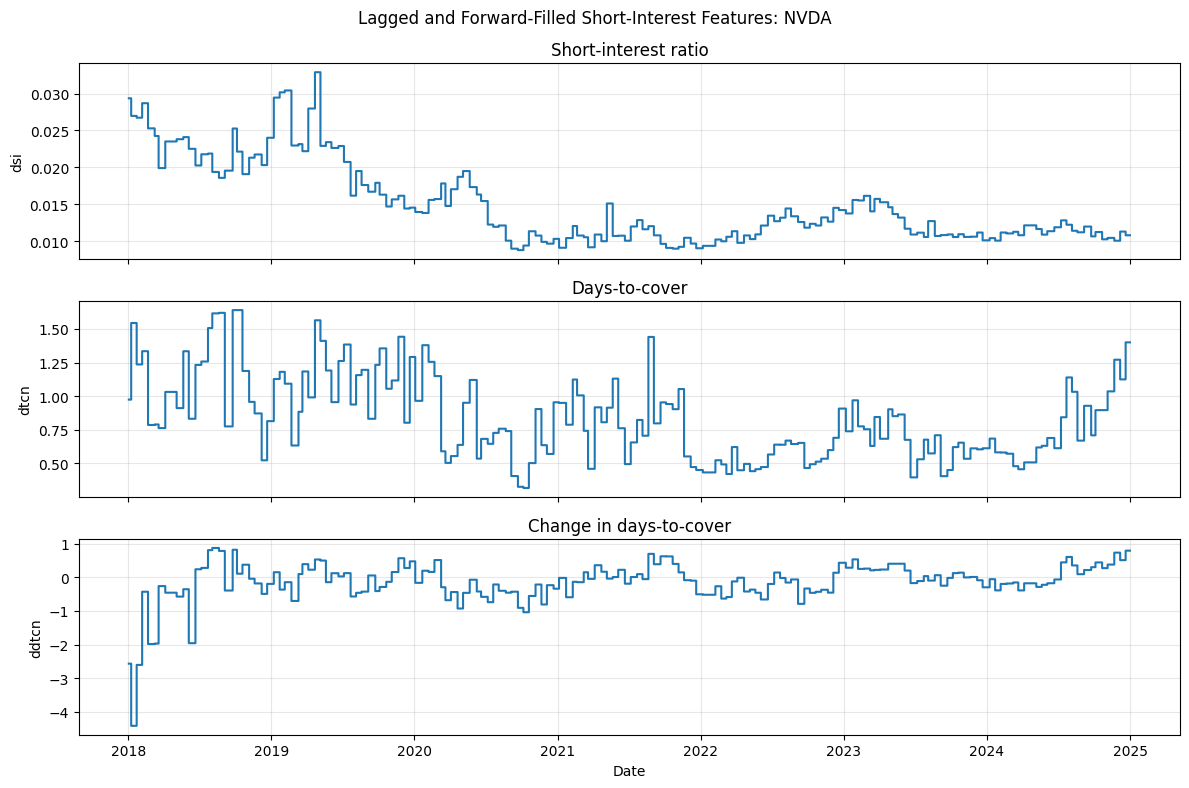

In [100]:
# Plot lagged short-interest features for a representative ticker.
import os
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Choose representative stock
# -----------------------------
plot_df = df.copy()
plot_df["date"] = pd.to_datetime(plot_df["date"])

# Specify the representative ticker to plot.
REP_TICKER = "NVDA"   # Can be changed to tickers such as "TSLA", "GME", or "MSFT".

rep = (
    plot_df.loc[plot_df["ticker"].eq(REP_TICKER),
                ["date", "ticker", "dsi", "dtcn", "ddtcn"]]
    .sort_values("date")
    .dropna(subset=["dsi", "dtcn", "ddtcn"], how="all")
)

# If the selected ticker has no data, choose the ticker with the most short-interest observations.
if rep.empty:
    counts = (
        plot_df.dropna(subset=["dsi", "dtcn", "ddtcn"], how="all")
        .groupby("ticker")
        .size()
        .sort_values(ascending=False)
    )
    REP_TICKER = counts.index[0]
    rep = (
        plot_df.loc[plot_df["ticker"].eq(REP_TICKER),
                    ["date", "ticker", "dsi", "dtcn", "ddtcn"]]
        .sort_values("date")
        .dropna(subset=["dsi", "dtcn", "ddtcn"], how="all")
    )

print("Representative ticker:", REP_TICKER)
print(rep.head())
print(rep.tail())

# -----------------------------
# Optional: restrict plot window
# -----------------------------
rep_plot = rep[
    (rep["date"] >= "2018-01-01") &
    (rep["date"] <= "2024-12-31")
].copy()

# -----------------------------
# Plot dsi
# -----------------------------
os.makedirs("figures", exist_ok=True)

cols = [
    ("dsi", "Short-interest ratio"),
    ("dtcn", "Days-to-cover"),
    ("ddtcn", "Change in days-to-cover"),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for ax, (col, title) in zip(axes, cols):
    ax.step(rep_plot["date"], rep_plot[col], where="post")
    ax.set_title(title)
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
fig.suptitle(f"Lagged and Forward-Filled Short-Interest Features: {REP_TICKER}", y=0.98)
plt.tight_layout()
plt.savefig("figures/short_interest_representative.png", dpi=300, bbox_inches="tight")
plt.show()

### Unused Index Inputs

Keep optional S&P constituent inputs documented but commented out because they are not used in the final pipeline.

In [101]:
# Keep optional S&P constituent inputs commented out because they are not used.
# sp400_constituents = pd.read_parquet('data/sp400_constituents.parquet')
# sp500_constituents = pd.read_parquet('data/sp500_constituents.parquet')
# sp500 = pd.read_parquet('data/sp500_tr.parquet')

## Filtering the Universe

Require at least one year of trading history and select the largest stocks by market capitalization for each yearly universe.

Build a yearly eligible universe using the previous year as the as-of window. Stocks must exist at the start of the previous year and rank in the top market-cap names at year end.

In [102]:
# Build the yearly top-market-cap universe with a previous-year history requirement.
def build_yearly_eligible_dict(
    df: pd.DataFrame,
    start_year: int = 2010,
    end_year: int = 2024,
    top_n: int = 1000,
) -> tuple[dict[int, list[int]], pd.DataFrame]:

    data = df.copy()
    data["year"] = data["date"].dt.year

    eligible_dict = {}
    eligible_tables = []

    for year in range(start_year, end_year + 1):
        asof_year = year - 1
        year_dates = data.loc[data["year"].eq(asof_year), "date"]
        if year_dates.empty:
            print(f"[Warning] No data for asof_year={asof_year}; universe_year={year} empty")
            eligible_dict[year] = []
            continue
        first_trading_date = year_dates.min()
        last_trading_date = year_dates.max()

        first_day_ids = set(
            data.loc[
                data["date"].eq(first_trading_date),
                "instrument_id"
            ].astype(int)
        )

        snapshot = data.loc[data["date"].eq(last_trading_date)].copy()

        # Keep only valid rows for the primary ticker universe.
        # The stock must already exist on the first trading day of the previous year.
        snapshot = snapshot.loc[
            snapshot["instrument_id"].astype(int).isin(first_day_ids)
        ].copy()

        # market_cap must be available.
        snapshot = snapshot.loc[snapshot["market_cap"].notna()].copy()

        # Select the top_n stocks by market capitalization.
        selected = (
            snapshot
            .sort_values("market_cap", ascending=False)
            .head(top_n)
            .copy()
        )

        selected["universe_year"] = year
        selected["asof_year"] = asof_year
        selected["first_trading_date_prev_year"] = first_trading_date
        selected["asof_date"] = last_trading_date
        selected["rank_mcap"] = np.arange(1, len(selected) + 1)

        eligible_dict[year] = selected["instrument_id"].astype(int).tolist()

        eligible_tables.append(
            selected[
                [
                    "universe_year",
                    "asof_year",
                    "first_trading_date_prev_year",
                    "asof_date",
                    "instrument_id",
                    "ticker",
                    "market_cap",
                    "rank_mcap",
                ]
            ].copy()
        )

        print(
            f"Universe {year}: "
            f"prev_year_first_date={first_trading_date.date()}, "
            f"asof_date={last_trading_date.date()}, "
            f"n_selected={len(selected)}"
        )

    eligible_table = pd.concat(eligible_tables, ignore_index=True)

    return eligible_dict, eligible_table


eligible_dict, eligible_table = build_yearly_eligible_dict(
    df,
    start_year=2010,
    end_year=2024,
    top_n=1000,
)

Universe 2010: prev_year_first_date=2009-01-02, asof_date=2009-12-31, n_selected=1000
Universe 2011: prev_year_first_date=2010-01-04, asof_date=2010-12-31, n_selected=1000
Universe 2012: prev_year_first_date=2011-01-03, asof_date=2011-12-30, n_selected=1000
Universe 2013: prev_year_first_date=2012-01-03, asof_date=2012-12-31, n_selected=1000
Universe 2014: prev_year_first_date=2013-01-02, asof_date=2013-12-31, n_selected=1000
Universe 2015: prev_year_first_date=2014-01-02, asof_date=2014-12-31, n_selected=1000
Universe 2016: prev_year_first_date=2015-01-02, asof_date=2015-12-31, n_selected=1000
Universe 2017: prev_year_first_date=2016-01-04, asof_date=2016-12-30, n_selected=1000
Universe 2018: prev_year_first_date=2017-01-03, asof_date=2017-12-29, n_selected=1000
Universe 2019: prev_year_first_date=2018-01-02, asof_date=2018-12-31, n_selected=1000
Universe 2020: prev_year_first_date=2019-01-02, asof_date=2019-12-31, n_selected=1000
Universe 2021: prev_year_first_date=2020-01-02, asof_d

### Save the Basic Universe

Save the yearly eligible universe dictionary so later notebooks or pipeline steps can reuse the same stock universe.

In [103]:
# Save the yearly eligible universe dictionary for later reuse.
import pickle

with open("data/eligible_dict.pkl", "wb") as f:
    pickle.dump(eligible_dict, f)

### Universe Evolution

Summarize the yearly universe and count names that disappear before the end of each selected year.

In [104]:
# Summarize how many selected stocks leave the universe during each year.
def summarize_yearly_universe_evolution(
    df: pd.DataFrame,
    eligible_table: pd.DataFrame,
    start_year: int = 2010,
    end_year: int = 2024,
) -> pd.DataFrame:
    data = df.copy()
    data["date"] = pd.to_datetime(data["date"])
    data["year"] = data["date"].dt.year

    summary_rows = []

    for year in range(start_year, end_year + 1):
        selected_ids = (
            eligible_table
            .loc[eligible_table["universe_year"].eq(year), "instrument_id"]
            .astype(int)
            .unique()
        )

        year_data = data.loc[
            data["year"].eq(year)
            & data["instrument_id"].astype(int).isin(selected_ids)
        ].copy()

        if year_data.empty:
            summary_rows.append({
                "year": year,
                "eligible_names_at_year_start": len(selected_ids),
                "mid_year_exits": np.nan,
                "last_trading_date": pd.NaT,
            })
            continue

        last_trading_date = year_data["date"].max()

        last_obs_by_stock = (
            year_data
            .groupby("instrument_id")["date"]
            .max()
        )

        # Mid-year exit: selected at year-start but last observation is before year-end
        mid_year_exits = (last_obs_by_stock < last_trading_date).sum()

        summary_rows.append({
            "year": year,
            "eligible_names_at_year_start": len(selected_ids),
            "mid_year_exits": int(mid_year_exits),
            "last_trading_date": last_trading_date,
        })

    return pd.DataFrame(summary_rows)


universe_evolution = summarize_yearly_universe_evolution(
    df=df,
    eligible_table=eligible_table,
    start_year=2010,
    end_year=2024,
)

universe_evolution

,year,eligible_names_at_year_start,mid_year_exits,last_trading_date
0,2010,1000,0,2010-12-31
1,2011,1000,0,2011-12-30
2,2012,1000,0,2012-12-31
3,2013,1000,0,2013-12-31
4,2014,1000,0,2014-12-31
5,2015,1000,0,2015-12-31
6,2016,1000,0,2016-12-30
7,2017,1000,0,2017-12-29
8,2018,1000,0,2018-12-31
9,2019,1000,0,2019-12-31


Convert the yearly universe dictionary to a long table, merge it into the main dataframe, and keep only rows inside each year's selected universe.

In [105]:
# Merge the yearly universe membership flag and keep only eligible yearly-universe rows.
eligible_long = pd.DataFrame(
    [
        {"year": year, "instrument_id": instrument_id}
        for year, ids in eligible_dict.items()
        for instrument_id in ids
    ]
)

eligible_long["in_yearly_universe"] = 1


df["date"] = pd.to_datetime(df["date"]).dt.normalize()
df["year"] = df["date"].dt.year

df = df.merge(
    eligible_long,
    how="left",
    on=["year", "instrument_id"],
    validate="m:1"
)

# ------------------------------------------------------------
# 4. Missing merge values mean the stock is not in that year's universe.
# ------------------------------------------------------------
df["in_yearly_universe"] = (
    df["in_yearly_universe"]
    .fillna(0)
    .astype(int)
)

# ------------------------------------------------------------
# 5. Keep only rows that belong to that year's universe.
# ------------------------------------------------------------
df_universe = df[df["in_yearly_universe"].eq(1)].copy()

df_universe

,ticker,instrument_id,date,open,high,low,close,volume,status,adj_factor,...,deps,earn_effective_date,trade_date,in_earn_window,piot_norm,dsi,dtcn,ddtcn,year,in_yearly_universe
265,HLT,1,2015-01-02,26.1961,26.2661,25.4762,25.9362,1225573.0,1.0,1.939594,...,0.00750,NaT,2015-01-05,False,0.875000,NaN,NaN,NaN,2015,1
266,HLT,1,2015-01-05,25.7462,25.8462,24.9963,25.0963,1444734.0,1.0,1.939593,...,0.00366,NaT,2015-01-06,False,0.875000,NaN,NaN,NaN,2015,1
267,HLT,1,2015-01-06,25.0463,25.0563,24.3564,24.8663,2341111.0,1.0,1.939597,...,0.00438,NaT,2015-01-07,False,0.875000,NaN,NaN,NaN,2015,1
268,HLT,1,2015-01-07,25.1663,25.3663,24.9164,25.2663,1531769.0,1.0,1.939591,...,0.00438,NaT,2015-01-08,False,0.875000,NaN,NaN,NaN,2015,1
269,HLT,1,2015-01-08,25.4862,26.0162,25.4063,25.9662,1435355.0,1.0,1.939591,...,0.00438,NaT,2015-01-09,False,0.875000,NaN,NaN,NaN,2015,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7882374,BNL,1611,2022-12-23,16.6700,16.7800,16.4600,16.7700,392000.0,1.0,0.784192,...,0.00000,NaT,2022-12-27,False,0.777778,0.088148,20.888611,12.413199,2022,1
7882375,BNL,1611,2022-12-27,16.7000,16.7900,16.5300,16.7600,623900.0,1.0,0.784195,...,0.00000,NaT,2022-12-28,False,0.777778,0.088148,20.888611,12.413199,2022,1
7882376,BNL,1611,2022-12-28,16.8800,17.0500,16.4150,16.4600,1044300.0,1.0,0.784192,...,0.00000,NaT,2022-12-29,False,0.777778,0.088148,20.888611,12.413199,2022,1
7882377,BNL,1611,2022-12-29,16.4000,16.4900,16.2000,16.2800,916000.0,1.0,0.797518,...,0.00000,NaT,2022-12-30,False,0.777778,0.088148,20.888611,12.413199,2022,1


### Missing Data in Yearly Universe

Plot the number of stocks available on each trading date after applying the yearly universe filter.

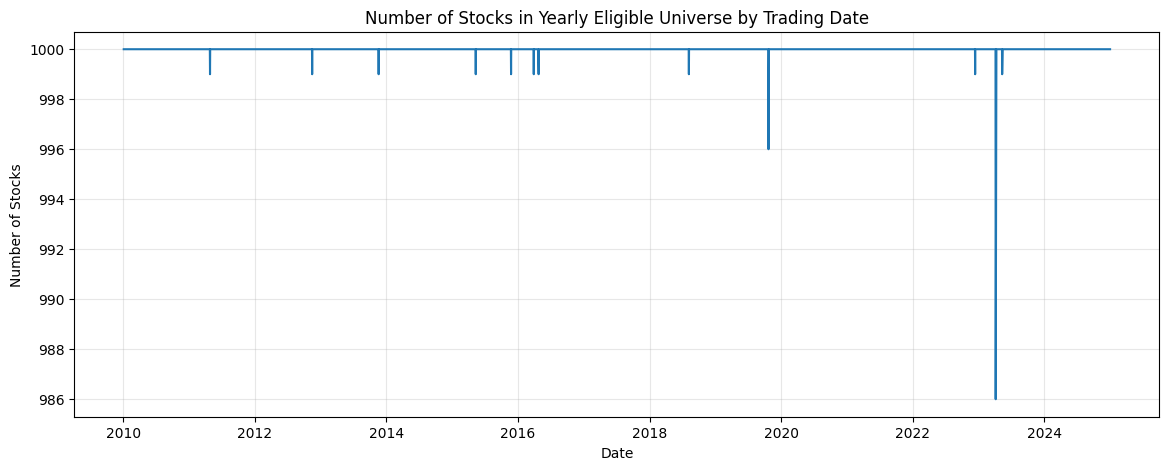

In [135]:
# Plot the daily number of stocks in the yearly eligible universe.
import matplotlib.pyplot as plt

df_universe["date"] = pd.to_datetime(df_universe["date"]).dt.normalize()

# Count the number of stocks on each trading date.
daily_universe_count = (
    df_universe
    .groupby("date")["instrument_id"]
    .nunique()
    .rename("n_stocks")
    .reset_index()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_universe_count["date"],
    daily_universe_count["n_stocks"]
)

plt.title("Number of Stocks in Yearly Eligible Universe by Trading Date")
plt.xlabel("Date")
plt.ylabel("Number of Stocks")
plt.grid(True, alpha=0.3)

plt.show()

Compare the expected yearly universe against the actual rows present each day to find missing eligible stocks.

In [136]:
# Identify expected universe members that are missing on each date.
# Actual set of stocks present in df_universe on each date.
actual_ids_by_date = (
    df_universe
    .groupby("date")["instrument_id"]
    .apply(lambda x: set(x.astype(int)))
)

# Find which expected eligible stocks are missing on each date.
missing_records = []

for date, actual_ids in actual_ids_by_date.items():
    year = date.year
    expected_ids = set(map(int, eligible_dict.get(year, [])))
    
    missing_ids = expected_ids - actual_ids
    
    if len(missing_ids) > 0:
        for instrument_id in sorted(missing_ids):
            missing_records.append({
                "date": date,
                "year": year,
                "instrument_id": instrument_id,
            })

missing_eligible = pd.DataFrame(missing_records)

missing_eligible

,date,year,instrument_id
0,2011-04-28,2011,344
1,2012-11-15,2012,930
2,2013-11-19,2013,1072
3,2015-05-12,2015,344
4,2015-11-24,2015,1072
5,2016-03-29,2016,1055
6,2016-04-25,2016,821
7,2018-08-07,2018,1584
8,2019-10-23,2019,505
9,2019-10-23,2019,636


## Sanity Check

Compute equal-weighted daily target returns across the eligible universe and plot cumulative log-return components.

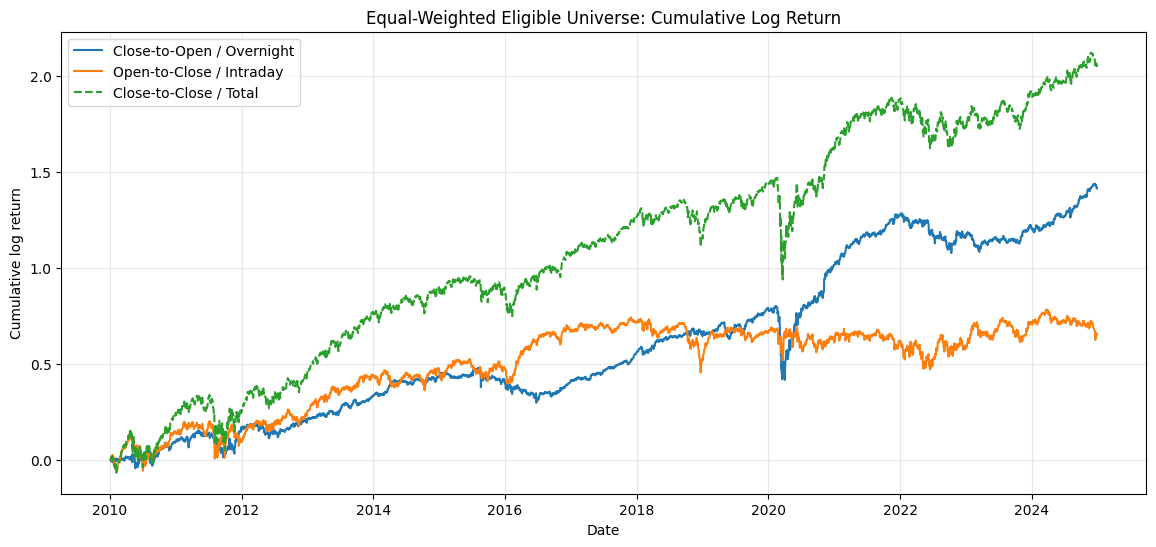

In [109]:
# Sanity-check average universe returns by plotting cumulative log returns.
return_cols = ["target_c2o_next_adj", "target_o2c_next_adj", "target_c2c_adj"]

# 3. Equal-weighted daily returns
valid_mask = df_universe[return_cols].notna().all(axis=1)

daily_returns = (
    df_universe.loc[valid_mask]
    .groupby("date")
    .agg(
        n_stocks=("instrument_id", "nunique"),
        overnight=("target_c2o_next_adj", "mean"),
        intraday=("target_o2c_next_adj", "mean"),
        close_to_close=("target_c2c_adj", "mean"),
    )
    .reset_index()
    .sort_values("date")
)

# Cumulative log returns

daily_returns["cum_log_overnight"] = np.log1p(daily_returns["overnight"]).cumsum()
daily_returns["cum_log_intraday"] = np.log1p(daily_returns["intraday"]).cumsum()
daily_returns["cum_log_close_to_close"] = np.log1p(daily_returns["close_to_close"]).cumsum()

# ============================================================
# 5. Plot cumulative log return
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    daily_returns["date"],
    daily_returns["cum_log_overnight"],
    label="Close-to-Open / Overnight"
)

plt.plot(
    daily_returns["date"],
    daily_returns["cum_log_intraday"],
    label="Open-to-Close / Intraday"
)

plt.plot(
    daily_returns["date"],
    daily_returns["cum_log_close_to_close"],
    label="Close-to-Close / Total",
    linestyle="--"
)

plt.title("Equal-Weighted Eligible Universe: Cumulative Log Return")
plt.xlabel("Date")
plt.ylabel("Cumulative log return")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Summarize yearly cumulative log returns and their dispersion across return components during the development window.

In [110]:
# Summarize yearly return dispersion over the development window.
# Ensure date is stored as datetime.
daily_returns["date"] = pd.to_datetime(daily_returns["date"])
daily_returns["year"] = daily_returns["date"].dt.year

# Keep only the development window.
daily_returns_dev = daily_returns[
    (daily_returns["year"] >= 2010) &
    (daily_returns["year"] <= 2024)
].copy()

# Compute yearly cumulative log returns.
yearly_log_returns = (
    daily_returns_dev
    .assign(
        C2O=np.log1p(daily_returns_dev["overnight"]),
        O2C=np.log1p(daily_returns_dev["intraday"]),
        C2C=np.log1p(daily_returns_dev["close_to_close"]),
    )
    .groupby("year")[["C2O", "O2C", "C2C"]]
    .sum()
)

# Component | Mean | Std | Min | Max
dispersion_table = (
    yearly_log_returns
    .agg(["mean", "std", "min", "max"])
    .T
    .rename(columns={
        "mean": "Mean",
        "std": "Std",
        "min": "Min",
        "max": "Max",
    })
)

print("Yearly cumulative log returns:")
display(yearly_log_returns)

print("Dispersion table:")
display(dispersion_table)

Yearly cumulative log returns:


,C2O,O2C,C2C
year,,,
2010,0.101751,0.148587,0.245691
2011,0.063435,-0.054443,0.014863
2012,0.048895,0.160530,0.203570
2013,0.117938,0.181815,0.297603
2014,0.098777,0.023751,0.128603
2015,-0.027122,0.011811,-0.024995
2016,0.011769,0.196213,0.206429
2017,0.143802,0.047834,0.192826
2018,0.085102,-0.183628,-0.092007


Dispersion table:


,Mean,Std,Min,Max
C2O,0.094493,0.098302,-0.106551,0.264466
O2C,0.043735,0.110966,-0.183628,0.196213
C2C,0.136551,0.136868,-0.147178,0.297603


## Defining a Capacity-Aware Universe

### Modeling Columns

Keep the core price, fundamental, earnings, short-interest, and target columns needed for capacity-aware filtering and feature engineering.

In [111]:
# Keep only the columns needed for capacity-aware filtering and feature engineering.
df = df[['instrument_id', 'date', 'open', 'high', 'low', 'close',
       'volume', 'adj_factor', 'adjusted_open', 'adjusted_high',
       'adjusted_low', 'adjusted_close', 'market_cap',
        'valuation_score', 'quality_score', 'health_score',
       'momentum_score', 'final_score', 'final_score_clean', 'value_trap',
       'gics_industry',
         'epsp', 'epsf', 'reps1', 'repsf4',
       'sue', 'inesp', 'inesn', 'reps41', 'repsfs', 'repsfl', 'deps',
       'piot_norm', 'in_earn_window',
         'dsi', 'dtcn', 'ddtcn', 'target_c2o_next_adj']]


### Eligibility Table

Define the capacity-aware eligibility table, including market-cap membership, price, ADV, volatility, earnings-window, and estimated impact constraints.

In [164]:
# Define the liquidity, volatility, earnings-window, and impact filters.
def build_eligibility_table(
    df_train: pd.DataFrame,
    eligible_dict: dict[int, list[int]],
    portfolio_aum: float,
    n_long: int = 200,
    n_short: int = 200,
    price_floor: float = 5.0,
    adv_multiple: float = 20.0,
    vol_window: int = 252,
    vol_floor: float = 0.10,
    vol_cap: float = 2.00,
    market_impact_k: float = 0.7,
) -> pd.DataFrame:
    """
    Build per-(stock, date) eligibility table using first-fail binding constraints.

    Filter order:
    1. MCAP_FAIL: not in year-start top 1000 universe
    2. PRICE_FAIL: close <= price_floor
    3. ADV_FAIL: ADV20 <= adv_multiple * per-stock target position
    4. VOL_FAIL: annualized 20-day realized volatility not in (vol_floor, vol_cap)
    5. EARN_WINDOW: in_earn_window == True
    6. OK: passes all filters

    Also computes implied participation rate and implied square-root impact slippage:
        f = per_stock_position / ADV20
        impact_bps = k * daily_vol * sqrt(f) * 1e4
    """

    df = df_train.copy()
    df["date"] = pd.to_datetime(df["date"])
    df["year"] = df["date"].dt.year
    df = df.sort_values(["instrument_id", "date"]).reset_index(drop=True)

    # -----------------------------
    # Per-stock target position
    # -----------------------------
    n_total_names = n_long + n_short
    per_stock_position = portfolio_aum / n_total_names

    # -----------------------------
    # Base universe membership
    # -----------------------------
    df["in_base_universe"] = False

    for year, ids in eligible_dict.items():
        year_mask = df["year"].eq(year)
        id_set = set(map(int, ids))
        df.loc[year_mask, "in_base_universe"] = (
            df.loc[year_mask, "instrument_id"].astype(int).isin(id_set)
        )

    # -----------------------------
    # Price filter
    # -----------------------------
    df["price_filter_pass"] = df["close"] > price_floor

    # -----------------------------
    # ADV20 filter
    # ADV20 = trailing 20-day mean of dollar volume
    # dollar volume = raw close * raw share volume
    # -----------------------------
    df["dollar_volume"] = df["close"] * df["volume"]

    df["adv20"] = (
        df.groupby("instrument_id")["dollar_volume"]
        .rolling(window=20, min_periods=20)
        .mean()
        .reset_index(level=0, drop=True)
    )

    adv_threshold = adv_multiple * per_stock_position

    df["adv_filter_pass"] = df["adv20"] > adv_threshold

    # -----------------------------
    # Realized volatility filter
    # annualized 20-day volatility from adjusted close-to-close returns
    # -----------------------------
    df["ret_cc_for_vol"] = (
        df.groupby("instrument_id")["adjusted_close"]
        .pct_change()
    )

    df["realized_vol_20d_daily"] = (
        df.groupby("instrument_id")["ret_cc_for_vol"]
        .rolling(window=vol_window, min_periods=vol_window)
        .std()
        .reset_index(level=0, drop=True)
    )

    df["realized_vol_20d_ann"] = (
        df["realized_vol_20d_daily"] * np.sqrt(252)
    )

    df["vol_filter_pass"] = (
        (df["realized_vol_20d_ann"] > vol_floor)
        & (df["realized_vol_20d_ann"] < vol_cap)
    )

    # -----------------------------
    # Implied participation and slippage
    # -----------------------------
    df["implied_participation_rate"] = (
        per_stock_position / df["adv20"]
    )

    # invalid ADV gives NaN, not inf
    df.loc[
        ~np.isfinite(df["implied_participation_rate"]),
        "implied_participation_rate"
    ] = np.nan

    df["slippage_commission_bps"] = (
        market_impact_k
        * df["realized_vol_20d_daily"]
        * np.sqrt(df["implied_participation_rate"])
        * 1e4 + 0.5
    )

    # If participation is negative/impossible, set slippage to NaN
    df.loc[
        df["implied_participation_rate"].le(0)
        | df["implied_participation_rate"].isna(),
        "slippage_commission_bps"
    ] = np.nan

    # -----------------------------
    # Earnings window filter
    # -----------------------------
    if "in_earn_window" not in df.columns:
        raise ValueError("df_train must contain column 'in_earn_window'.")

    df["earn_filter_pass"] = ~df["in_earn_window"].fillna(False).astype(bool)

    # -----------------------------
    # First-fail binding constraint
    # -----------------------------
    df["eligibility_reason"] = "OK"

    df.loc[~df["in_base_universe"], "eligibility_reason"] = "MCAP_FAIL"

    ok = df["eligibility_reason"].eq("OK")
    df.loc[ok & ~df["price_filter_pass"], "eligibility_reason"] = "PRICE_FAIL"

    ok = df["eligibility_reason"].eq("OK")
    df.loc[ok & ~df["adv_filter_pass"], "eligibility_reason"] = "ADV_FAIL"

    ok = df["eligibility_reason"].eq("OK")
    df.loc[ok & ~df["vol_filter_pass"], "eligibility_reason"] = "VOL_FAIL"

    ok = df["eligibility_reason"].eq("OK")
    df.loc[ok & ~df["earn_filter_pass"], "eligibility_reason"] = "EARN_WINDOW"

    df["is_eligible"] = df["eligibility_reason"].eq("OK")

    # -----------------------------
    # Useful output columns
    # -----------------------------
    output_cols = [
        "instrument_id",
        "ticker",
        "date",
        "year",
        "in_base_universe",
        "close",
        "adjusted_close",
        "volume",
        "dollar_volume",
        "adv20",
        "implied_participation_rate",
        "realized_vol_20d_daily",
        "realized_vol_20d_ann",
        "slippage_commission_bps",
        "in_earn_window",
        "eligibility_reason",
        "is_eligible",
    ]

    existing_output_cols = [c for c in output_cols if c in df.columns]

    eligibility_table = df[existing_output_cols].copy()

    eligibility_table.attrs["portfolio_aum"] = portfolio_aum
    eligibility_table.attrs["n_long"] = n_long
    eligibility_table.attrs["n_short"] = n_short
    eligibility_table.attrs["per_stock_position"] = per_stock_position
    eligibility_table.attrs["adv_threshold"] = adv_threshold
    eligibility_table.attrs["adv_multiple"] = adv_multiple
    eligibility_table.attrs["participation_cap_equivalent"] = 1 / adv_multiple
    eligibility_table.attrs["market_impact_k"] = market_impact_k

    return eligibility_table

Build eligibility tables for 50M, 250M, and 1B portfolio AUM assumptions.

In [165]:
# Build eligibility tables for three portfolio AUM levels.
eligibility_50m = build_eligibility_table(
    df_train=df,
    eligible_dict=eligible_dict,
    portfolio_aum=50_000_000,
)

eligibility_250m = build_eligibility_table(
    df_train=df,
    eligible_dict=eligible_dict,
    portfolio_aum=250_000_000,
)

eligibility_1b = build_eligibility_table(
    df_train=df,
    eligible_dict=eligible_dict,
    portfolio_aum=1_000_000_000,
)

/var/folders/yb/8ggp9gv52cb8_8xlnpwq7qz40000gn/T/ipykernel_69621/2658066504.py:135: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["earn_filter_pass"] = ~df["in_earn_window"].fillna(False).astype(bool)
/var/folders/yb/8ggp9gv52cb8_8xlnpwq7qz40000gn/T/ipykernel_69621/2658066504.py:135: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["earn_filter_pass"] = ~df["in_earn_window"].fillna(False).astype(bool)
/var/folders/yb/8ggp9gv52cb8_8xlnpwq7qz40000gn/T/ipykernel_69621/2658066504.py:135: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .

Plot the daily number of eligible stocks for each AUM level after all eligibility filters are applied.

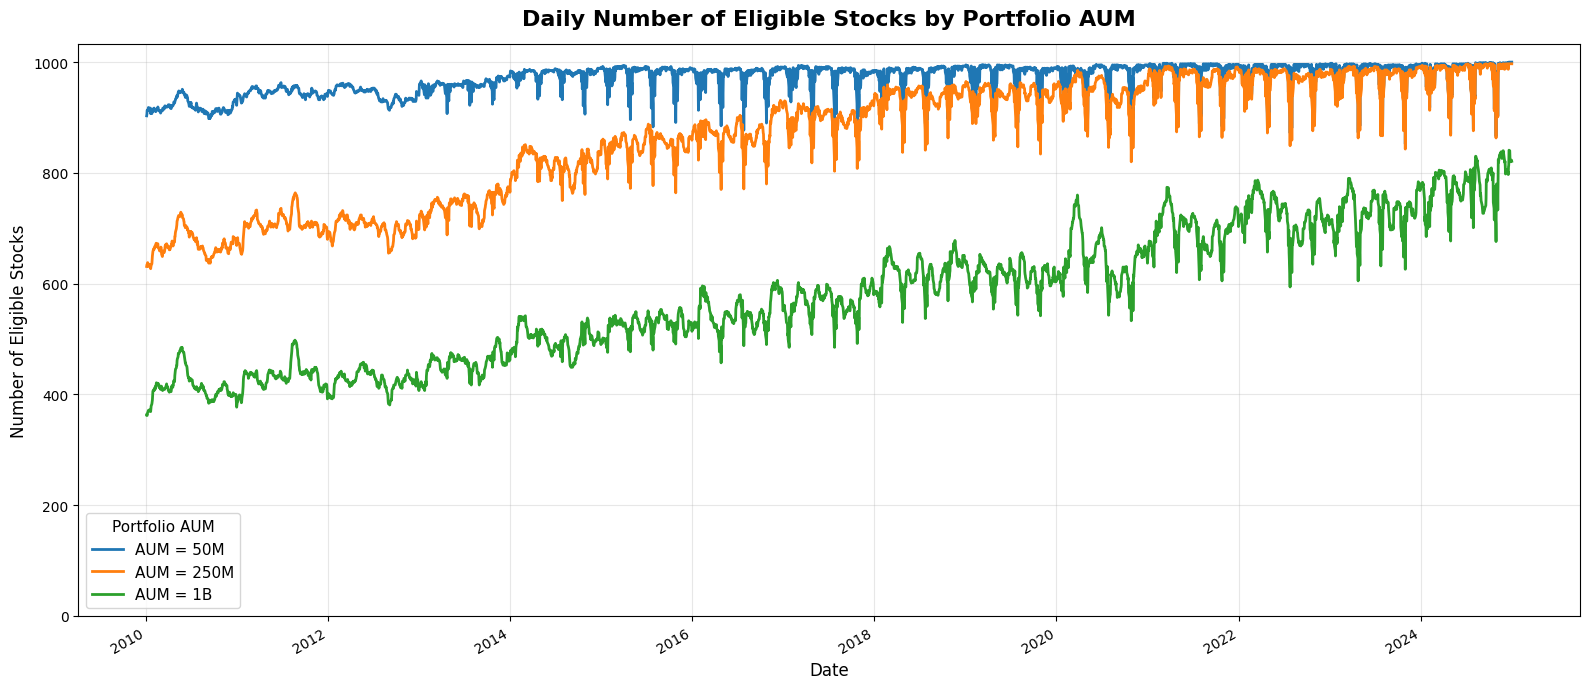

In [166]:
# Plot daily eligible stock counts across AUM levels.
import matplotlib.pyplot as plt
import pandas as pd

def plot_eligible_count_by_aum(
    eligibility_50m,
    eligibility_250m,
    eligibility_1b,
):
    # Build daily eligible counts.
    s_50m = (
        eligibility_50m.loc[eligibility_50m["is_eligible"]]
        .groupby("date")
        .size()
        .rename("AUM = 50M")
    )

    s_250m = (
        eligibility_250m.loc[eligibility_250m["is_eligible"]]
        .groupby("date")
        .size()
        .rename("AUM = 250M")
    )

    s_1b = (
        eligibility_1b.loc[eligibility_1b["is_eligible"]]
        .groupby("date")
        .size()
        .rename("AUM = 1B")
    )

    counts = pd.concat([s_50m, s_250m, s_1b], axis=1).sort_index()
    counts.index = pd.to_datetime(counts.index)

    # Plot
    fig, ax = plt.subplots(figsize=(16, 7))

    counts.plot(ax=ax, linewidth=2.0)

    ax.set_title(
        "Daily Number of Eligible Stocks by Portfolio AUM",
        fontsize=16,
        fontweight="bold",
        pad=14,
    )
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Number of Eligible Stocks", fontsize=12)

    ax.grid(True, alpha=0.3)
    ax.legend(title="Portfolio AUM", fontsize=11, title_fontsize=11)

    ax.set_ylim(bottom=0)

    plt.tight_layout()

    plt.show()

    return counts


eligible_count_by_aum = plot_eligible_count_by_aum(
    eligibility_50m=eligibility_50m,
    eligibility_250m=eligibility_250m,
    eligibility_1b=eligibility_1b,
)

Create a pooled dataset of estimated slippage plus commission values across AUM levels for later distribution plots.

In [167]:
# Build the slippage and commission distribution dataset across AUM levels.
from pathlib import Path

Path("figures").mkdir(parents=True, exist_ok=True)

def build_cost_distribution_df(
    eligibility_50m: pd.DataFrame,
    eligibility_250m: pd.DataFrame,
    eligibility_1b: pd.DataFrame,
    cost_col: str = "slippage_commission_bps",
    only_eligible: bool = True,
) -> pd.DataFrame:
    dfs = []

    inputs = {
        "50M": eligibility_50m,
        "250M": eligibility_250m,
        "1B": eligibility_1b,
    }

    for aum_label, df in inputs.items():
        temp = df.copy()

        if only_eligible:
            temp = temp.loc[temp["is_eligible"]].copy()

        temp = temp.loc[
            temp[cost_col].notna(),
            ["date", "instrument_id", "ticker", cost_col,
             "implied_participation_rate", "realized_vol_20d_daily", "adv20"]
            if "ticker" in temp.columns
            else ["date", "instrument_id", cost_col,
                  "implied_participation_rate", "realized_vol_20d_daily", "adv20"]
        ].copy()

        temp["AUM"] = aum_label
        dfs.append(temp)

    out = pd.concat(dfs, ignore_index=True)
    out["date"] = pd.to_datetime(out["date"])

    return out


cost_dist_df = build_cost_distribution_df(
    eligibility_50m=eligibility_50m,
    eligibility_250m=eligibility_250m,
    eligibility_1b=eligibility_1b,
    cost_col="slippage_commission_bps",
    only_eligible=True,
)

### Slippage Estimate

Estimate market impact from participation in ADV rather than using one fixed slippage number. Stocks that imply excessive participation fail the ADV constraint, while eligible rows retain a continuous estimated trading-cost value.

Plot the distribution of estimated slippage plus commission by AUM, trimming the upper tail only for visualization.

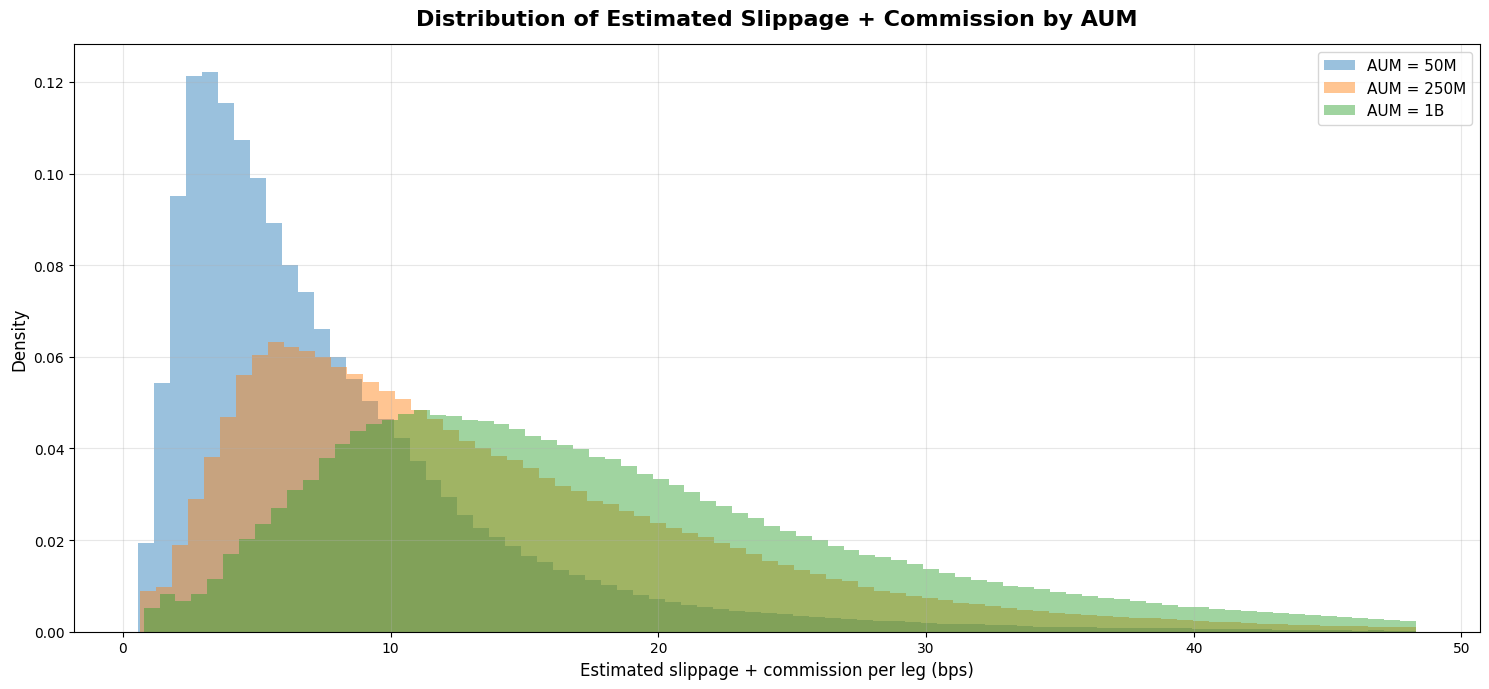

In [168]:
# Plot the estimated slippage plus commission distribution.
def plot_cost_histogram(
    cost_dist_df: pd.DataFrame,
    cost_col: str = "slippage_commission_bps",
    save_path: str = "figures/slippage_commission_distribution_hist.png",
    upper_quantile: float = 0.99,
):
    plot_df = cost_dist_df.copy()

    # Limit the plot to the pooled 99th percentile so extreme values do not dominate the chart.
    x_max = plot_df[cost_col].quantile(upper_quantile)
    plot_df = plot_df[plot_df[cost_col] <= x_max].copy()

    fig, ax = plt.subplots(figsize=(15, 7))

    for aum_label in ["50M", "250M", "1B"]:
        x = plot_df.loc[plot_df["AUM"].eq(aum_label), cost_col].dropna()
        ax.hist(
            x,
            bins=80,
            alpha=0.45,
            density=True,
            label=f"AUM = {aum_label}",
        )

    ax.set_title(
        "Distribution of Estimated Slippage + Commission by AUM",
        fontsize=16,
        fontweight="bold",
        pad=14,
    )
    ax.set_xlabel("Estimated slippage + commission per leg (bps)", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_cost_histogram(cost_dist_df)

Summarize which eligibility constraint is binding each year for each AUM setting.

In [169]:
# Summarize the first binding eligibility constraint by year.
def binding_constraint_distribution(eligibility_table: pd.DataFrame) -> pd.DataFrame:
    dist = (
        eligibility_table
        .groupby(["year", "eligibility_reason"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )

    reason_order = [
        "year",
        "OK",
        "MCAP_FAIL",
        "PRICE_FAIL",
        "ADV_FAIL",
        "VOL_FAIL",
        "EARN_WINDOW",
    ]

    cols = [c for c in reason_order if c in dist.columns]
    other_cols = [c for c in dist.columns if c not in cols]

    return dist[cols + other_cols]


dist_50m = binding_constraint_distribution(eligibility_50m)
dist_250m = binding_constraint_distribution(eligibility_250m)
dist_1b = binding_constraint_distribution(eligibility_1b)

display(dist_50m)
display(dist_250m)
display(dist_1b)

eligibility_reason,year,OK,MCAP_FAIL,PRICE_FAIL,ADV_FAIL,VOL_FAIL,EARN_WINDOW
0,2000,0,232361,0,0,0,0
1,2001,0,233287,0,0,0,0
2,2002,0,243320,0,0,0,0
3,2003,0,247573,0,0,0,0
4,2004,0,254999,0,0,0,0
5,2005,0,262648,0,0,0,0
6,2006,0,267958,0,0,0,0
7,2007,0,276855,0,0,0,0
8,2008,0,285222,0,0,0,0
9,2009,0,286901,0,0,0,0


eligibility_reason,year,OK,MCAP_FAIL,PRICE_FAIL,ADV_FAIL,VOL_FAIL,EARN_WINDOW
0,2000,0,232361,0,0,0,0
1,2001,0,233287,0,0,0,0
2,2002,0,243320,0,0,0,0
3,2003,0,247573,0,0,0,0
4,2004,0,254999,0,0,0,0
5,2005,0,262648,0,0,0,0
6,2006,0,267958,0,0,0,0
7,2007,0,276855,0,0,0,0
8,2008,0,285222,0,0,0,0
9,2009,0,286901,0,0,0,0


eligibility_reason,year,OK,MCAP_FAIL,PRICE_FAIL,ADV_FAIL,VOL_FAIL,EARN_WINDOW
0,2000,0,232361,0,0,0,0
1,2001,0,233287,0,0,0,0
2,2002,0,243320,0,0,0,0
3,2003,0,247573,0,0,0,0
4,2004,0,254999,0,0,0,0
5,2005,0,262648,0,0,0,0
6,2006,0,267958,0,0,0,0
7,2007,0,276855,0,0,0,0
8,2008,0,285222,0,0,0,0
9,2009,0,286901,0,0,0,0


## Participation Cap and Implied Slippage

Use the square-root impact model to estimate one-way slippage at a 10% ADV participation cap for representative large-cap and lower-cap names in the selected universe.

Compute median cap-level implied slippage for large-cap and lower-cap buckets within the annual top-1000 universe.

In [170]:
# Compute cap-level slippage examples for large-cap and lower-cap buckets.
import numpy as np
import pandas as pd

def compute_cap_level_slippage_examples(
    eligibility_table: pd.DataFrame,
    annual_universe_table: pd.DataFrame,
    participation_cap: float = 0.10,
    k: float = 0.7,
) -> pd.DataFrame:
    """
    Compute implied one-way square-root impact at participation cap
    for large-cap and lower-cap buckets within the top-1000 universe.
    """

    df = eligibility_table.copy()
    df["date"] = pd.to_datetime(df["date"])
    df["year"] = df["date"].dt.year

    ranks = annual_universe_table[
        ["universe_year", "instrument_id", "rank_mcap"]
    ].copy()

    ranks = ranks.rename(columns={"universe_year": "year"})

    df = df.merge(
        ranks,
        how="left",
        on=["year", "instrument_id"],
        validate="m:1"
    )

    # Use only rows that pass all eligibility filters
    df = df[df["is_eligible"]].copy()

    # Define buckets inside the annual top-1000 universe
    conditions = [
        df["rank_mcap"].between(1, 250),
        df["rank_mcap"].between(751, 1000),
    ]

    choices = [
        "Large-cap bucket: rank 1-250",
        "Lower-cap bucket: rank 751-1000",
    ]

    df["bucket"] = np.select(conditions, choices, default=np.nan)
    df = df[df["bucket"].notna()].copy()

    # Daily volatility from annualized volatility
    df["sigma_daily"] = df["realized_vol_20d_ann"] / np.sqrt(252)

    # Cap-level implied impact in bps
    df["impact_bps_at_cap"] = (
        k
        * df["sigma_daily"]
        * np.sqrt(participation_cap)
        * 1e4
    )

    summary = (
        df.groupby("bucket")
        .agg(
            median_annualized_vol=("realized_vol_20d_ann", "median"),
            median_daily_vol=("sigma_daily", "median"),
            implied_slippage_bps_at_10pct_adv=("impact_bps_at_cap", "median"),
            median_adv20=("adv20", "median"),
            n_stock_days=("instrument_id", "size"),
        )
        .reset_index()
    )

    return summary


slippage_examples_250m = compute_cap_level_slippage_examples(
    eligibility_table=eligibility_250m,
    annual_universe_table=eligible_table,
    participation_cap=0.10,
    k=0.7,
)

slippage_examples_250m

,bucket,median_annualized_vol,median_daily_vol,implied_slippage_bps_at_10pct_adv,median_adv20,n_stock_days
0,Large-cap bucket: rank 1-250,0.247334,0.015581,34.489107,2.999670e+08,931070
1,Lower-cap bucket: rank 751-1000,0.345211,0.021746,48.137374,2.738464e+07,581702
2,nan,0.291264,0.018348,40.614764,7.130892e+07,1746637


Save compact eligibility outputs for each AUM level after keeping the columns needed by later modeling steps.

In [171]:
# Save compact eligibility tables for each AUM level.
eligibility_50m = eligibility_50m[['instrument_id', 'date', 'slippage_commission_bps', 'eligibility_reason', 'is_eligible']].dropna(subset='slippage_commission_bps').reset_index(drop=True)
eligibility_250m = eligibility_250m[['instrument_id', 'date', 'slippage_commission_bps', 'eligibility_reason', 'is_eligible']].dropna(subset='slippage_commission_bps').reset_index(drop=True)
eligibility_1b = eligibility_1b[['instrument_id', 'date', 'slippage_commission_bps', 'eligibility_reason', 'is_eligible']].dropna(subset='slippage_commission_bps').reset_index(drop=True)

eligibility_50m.to_parquet('data/eligibility_50m.parquet')
eligibility_250m.to_parquet('data/eligibility_250m.parquet')
eligibility_1b.to_parquet('data/eligibility_1b.parquet')

## Filtering the Short Leg for Borrow Cost

Define a hard-to-borrow proxy by ranking short-interest metrics cross-sectionally, combining them into a score, assigning borrow tiers, and mapping tiers to annualized borrow rates.

In [172]:
# Define a hard-to-borrow proxy from cross-sectional short-interest ranks.
import numpy as np
import pandas as pd


def add_hard_to_borrow_proxy(
    df: pd.DataFrame,
    short_cols: list[str] = ["dsi", "dtcn", "ddtcn"],
    tier_b_threshold: float = 0.80,
    tier_c_threshold: float = 0.95,
    dsi_override_threshold: float = 0.95,
    dtcn_override_threshold: float = 0.9,
) -> pd.DataFrame:

    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["date", "instrument_id"]).reset_index(drop=True)

    missing_cols = [c for c in short_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing short-interest columns: {missing_cols}")

    # -----------------------------
    # Cross-sectional percentile ranks by date
    # -----------------------------
    for col in short_cols:
        rank_col = f"{col}_rank_pct"

        df[rank_col] = (
            df.groupby("date")[col]
            .rank(method="average", pct=True)
        )

        df[rank_col] = df[rank_col].fillna(0.0)

    # -----------------------------
    # Weighted hard-to-borrow score
    # -----------------------------
    df["htb_score"] = (
        0.5 * df["dsi_rank_pct"]
        + 0.30 * df["dtcn_rank_pct"]
        + 0.20 * df["ddtcn_rank_pct"]
    )

    # -----------------------------
    # Base tier assignment
    # -----------------------------
    df["borrow_tier"] = "A"

    df.loc[
        (df["htb_score"] >= tier_b_threshold)
        & (df["htb_score"] < tier_c_threshold),
        "borrow_tier"
    ] = "B"

    df.loc[
        df["htb_score"] >= tier_c_threshold,
        "borrow_tier"
    ] = "C"

    # -----------------------------
    # Extreme short-interest override
    # -----------------------------
    extreme_level_mask = (
        (df["dsi_rank_pct"] >= dsi_override_threshold)
        & (df["dtcn_rank_pct"] >= dtcn_override_threshold)
    )

    df.loc[extreme_level_mask, "borrow_tier"] = "C"

    # -----------------------------
    # Borrow rates
    # -----------------------------
    borrow_rate_map = {
        "A": 0.0040,  # 40 bps p.a.
        "B": 0.0200,  # 200 bps p.a.
        "C": 0.0800,  # 800 bps p.a.
    }

    df["borrow_rate_pa"] = df["borrow_tier"].map(borrow_rate_map)
    df["borrow_rate_daily"] = df["borrow_rate_pa"] / 252

    df["is_hard_to_borrow_moderate"] = df["borrow_tier"].isin(["B", "C"])
    df["is_hard_to_borrow_high"] = df["borrow_tier"].eq("C")

    return df

### Hard-to-Borrow Proxy

Rank DSI, DTCN, and DDTCN within each date, combine the ranks into a weighted score, and use the score to classify borrow difficulty.

Apply the hard-to-borrow proxy to the yearly universe and summarize the overall distribution of borrow tiers.

In [173]:
# Apply the hard-to-borrow proxy and summarize tier frequencies.
df_hardtoborrow = add_hard_to_borrow_proxy(df_universe)


tier_dist = (
    df_hardtoborrow
    .groupby("borrow_tier")
    .size()
    .rename("stock_days")
    .reset_index()
)

tier_dist["fraction"] = tier_dist["stock_days"] / tier_dist["stock_days"].sum()

tier_dist

,borrow_tier,stock_days,fraction
0,A,3292240,0.872354
1,B,369930,0.098021
2,C,111801,0.029624


Summarize borrow-tier counts by year over the 2010-2024 window.

In [174]:
# Summarize hard-to-borrow tiers by year.
df_hardtoborrow["year"] = df_hardtoborrow["date"].dt.year

tier_dist_by_year = (
    df_hardtoborrow
    .groupby(["year", "borrow_tier"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

tier_dist_by_year_2010_2024 = tier_dist_by_year[
    (tier_dist_by_year["year"] >= 2010)
    & (tier_dist_by_year["year"] <= 2024)
].copy()

tier_dist_by_year_2010_2024

borrow_tier,year,A,B,C
0,2010,220808,25095,6097
1,2011,221268,24249,6482
2,2012,219876,23141,6982
3,2013,217499,26460,8040
4,2014,220519,23250,8231
5,2015,220481,23475,8042
6,2016,219273,25593,7132
7,2017,216000,28075,6925
8,2018,218288,24889,7822
9,2019,219166,25110,7719


Inspect a selected stock event window to verify how short-interest ranks map into the hard-to-borrow score and tier.

In [175]:
# Inspect the hard-to-borrow proxy around a selected stock event window.
import pandas as pd

def inspect_borrow_proxy_event(
    df: pd.DataFrame,
    ticker: str,
    start: str,
    end: str,
) -> pd.DataFrame:
    out = df.copy()
    out["date"] = pd.to_datetime(out["date"])

    cols = [
        "date",
        "instrument_id",
        "dsi",
        "dtcn",
        "ddtcn",
        "dsi_rank_pct",
        "dtcn_rank_pct",
        "ddtcn_rank_pct",
        "htb_score",
        "borrow_tier",
        "borrow_rate_pa",
        "is_eligible"
    ]

    cols = [c for c in cols if c in out.columns]

    event = (
        out.loc[
            out["instrument_id"].eq(ticker)
            & out["date"].between(pd.to_datetime(start), pd.to_datetime(end)),
            cols
        ]
        .sort_values("date")
        .copy()
    )

    return event


tsla_event = inspect_borrow_proxy_event(
    df_hardtoborrow,
    ticker=123,
    start="2019-02-10",
    end="2020-01-01",
)

tsla_event[tsla_event['borrow_tier']!='A']

,date,instrument_id,dsi,dtcn,ddtcn,dsi_rank_pct,dtcn_rank_pct,ddtcn_rank_pct,htb_score,borrow_tier,borrow_rate_pa
2402110,2019-07-22,123,0.234220,5.183508,1.725235,0.992965,0.625126,0.805025,0.845025,B,0.02
2403110,2019-07-23,123,0.234220,5.183508,1.725235,0.992965,0.625126,0.805025,0.845025,B,0.02
2404110,2019-07-24,123,0.234220,5.183508,1.725235,0.992965,0.625126,0.805025,0.845025,B,0.02
2405110,2019-07-25,123,0.234220,5.183508,1.725235,0.992965,0.625126,0.805025,0.845025,B,0.02
2406110,2019-07-26,123,0.234220,5.183508,1.725235,0.992965,0.625126,0.805025,0.845025,B,0.02
2407110,2019-07-29,123,0.234220,5.183508,1.725235,0.992965,0.625126,0.805025,0.845025,B,0.02
2408110,2019-07-30,123,0.234220,5.183508,1.725235,0.992965,0.625126,0.805025,0.845025,B,0.02
2409110,2019-07-31,123,0.234220,5.183508,1.725235,0.992965,0.625126,0.805025,0.845025,B,0.02
2410110,2019-08-01,123,0.234220,5.183508,1.725235,0.992965,0.625126,0.805025,0.845025,B,0.02
2411110,2019-08-02,123,0.234220,5.183508,1.725235,0.992965,0.625126,0.805025,0.845025,B,0.02


Inspect the columns produced by the hard-to-borrow transformation.

In [176]:
# Inspect columns in the hard-to-borrow dataframe.
df_hardtoborrow.columns

Index(['ticker', 'instrument_id', 'date', 'open', 'high', 'low', 'close',
       'volume', 'status', 'adj_factor', 'adjusted_open', 'adjusted_high',
       'adjusted_low', 'target_c2o_next_adj', 'target_o2c_next_adj',
       'target_c2c_adj', 'valuation_score', 'quality_score', 'health_score',
       'momentum_score', 'final_score', 'final_score_clean', 'value_trap',
       'market_cap', 'adjusted_close', 'gics_sector', 'gics_group',
       'gics_industry', 'gics_subindustry', 'epsp', 'epsf', 'reps1', 'repsf4',
       'sue', 'inesp', 'inesn', 'reps41', 'repsfs', 'repsfl', 'nspc5', 'deps',
       'earn_effective_date', 'trade_date', 'in_earn_window', 'piot_norm',
       'dsi', 'dtcn', 'ddtcn', 'year', 'in_yearly_universe', 'dsi_rank_pct',
       'dtcn_rank_pct', 'ddtcn_rank_pct', 'htb_score', 'borrow_tier',
       'borrow_rate_pa', 'borrow_rate_daily', 'is_hard_to_borrow_moderate',
       'is_hard_to_borrow_high'],
      dtype='object')

Save hard-to-borrow proxy features and borrow-rate assumptions for downstream model construction.

In [ ]:
# Save hard-to-borrow proxy features for later modeling.
df_hardtoborrow[
    ['instrument_id', 'date', 'dsi_rank_pct', 'dtcn_rank_pct', 'ddtcn_rank_pct',
       'htb_score', 'borrow_tier', 'borrow_rate_pa', 'borrow_rate_daily']
].to_parquet('data/df_hardtoborrow.parquet')

: 

## Feature Engineering

Define a helper that extracts the rolling lookback history needed to compute price-volume factors for each annual universe.

In [162]:
# Select rolling lookback data for one annual universe.
def get_monthly_factor_mining_data(
    df: pd.DataFrame,
    target_year: int,
    target_month: int,
    symbol_col: str = "instrument_id",
    time_col: str = "date",
    pool_dict: dict = None,
    lookback_months: int = 37,
) -> pd.DataFrame:

    if target_month < 1 or target_month > 12:
        raise ValueError("target_month must be between 1 and 12")

    if target_year not in pool_dict:
        raise ValueError(f"target_year={target_year} was not found in pool_dict")

    out = df.copy()
    out[time_col] = pd.to_datetime(out[time_col])
    out = out.sort_values([symbol_col, time_col]).reset_index(drop=True)

    target_month_start = pd.Timestamp(year=target_year, month=target_month, day=1)
    start_month = target_month_start - pd.DateOffset(months=lookback_months)

    out = out[
        (out[time_col] >= start_month) &
        (out[time_col] <= pd.Timestamp(year=target_year, month=12, day=31)) &
        (out[symbol_col].isin(pool_dict[target_year]))
    ].reset_index(drop=True)

    
    return out



### Build Yearly Lookback Panel

For each yearly universe, keep a 37-month lookback window so lagged and rolling price-volume features can be computed without using future universe membership.

Create the combined lookback panel for all annual universes and remove duplicate stock-date rows.

In [140]:
# Build one combined lookback panel for all yearly universes.
all_dfs = []

for y in range(2010, 2025):
    df_tem = get_monthly_factor_mining_data(
        df=df,
        target_year=y,
        target_month=1,
        pool_dict=eligible_dict,
        lookback_months=50
    )
    all_dfs.append(df_tem)

df_all = (
    pd.concat(all_dfs, axis=0, ignore_index=True)
    .drop_duplicates(subset=["instrument_id", "date"], keep="last")
    .reset_index(drop=True)
)
df_all

,instrument_id,date,open,high,low,close,volume,adj_factor,adjusted_open,adjusted_high,...,reps41,repsfs,repsfl,deps,piot_norm,in_earn_window,dsi,dtcn,ddtcn,target_c2o_next_adj
0,2,2005-11-01,18.33,18.330,18.01,18.14,1511100.0,0.472310,8.657439,8.657439,...,NaN,NaN,NaN,NaN,0.666667,False,0.032490,10.638950,3.295643,0.000003
1,2,2005-11-02,18.05,18.260,17.98,18.18,2902200.0,0.472310,8.525200,8.624385,...,NaN,NaN,NaN,NaN,0.666667,False,0.032490,10.638950,3.295643,0.005030
2,2,2005-11-03,18.18,18.180,17.85,17.91,1681800.0,0.472312,8.586624,8.586624,...,NaN,NaN,NaN,NaN,0.666667,False,0.032490,10.638950,3.295643,-0.000009
3,2,2005-11-04,18.00,18.050,17.92,17.98,1077200.0,0.472314,8.501646,8.525262,...,NaN,NaN,NaN,NaN,0.666667,False,0.036258,10.199693,-1.625336,-0.000551
4,2,2005-11-07,17.98,18.090,17.88,17.97,1228500.0,0.472309,8.492123,8.544077,...,NaN,NaN,NaN,NaN,0.666667,False,0.036258,10.199693,-1.625336,-0.001673
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5218251,1605,2024-12-24,118.53,119.565,117.96,118.74,1725800.0,0.998341,118.333348,119.366631,...,-0.001846,-0.000430,-0.004045,0.0132,0.888889,False,0.040405,2.241569,0.420790,-0.015228
5218252,1605,2024-12-26,118.00,120.100,117.77,118.88,2188900.0,0.998343,117.804458,119.900978,...,-0.001846,-0.000438,-0.004053,0.0132,0.888889,False,0.040405,2.241569,0.420790,-0.024153
5218253,1605,2024-12-27,117.07,118.000,113.48,115.11,3813100.0,0.998341,116.875748,117.804205,...,-0.001846,-0.000209,-0.003825,0.0132,0.888889,False,0.040405,2.241569,0.420790,0.001978
5218254,1605,2024-12-30,112.33,118.200,112.23,116.16,3663200.0,0.998338,112.143364,118.003611,...,-0.001846,-0.000275,-0.003890,0.0132,0.888889,False,0.040405,2.241569,0.420790,NaN


## Missing-Value Diagnostics


Plot daily missing-value counts for every column that contains at least one missing value.


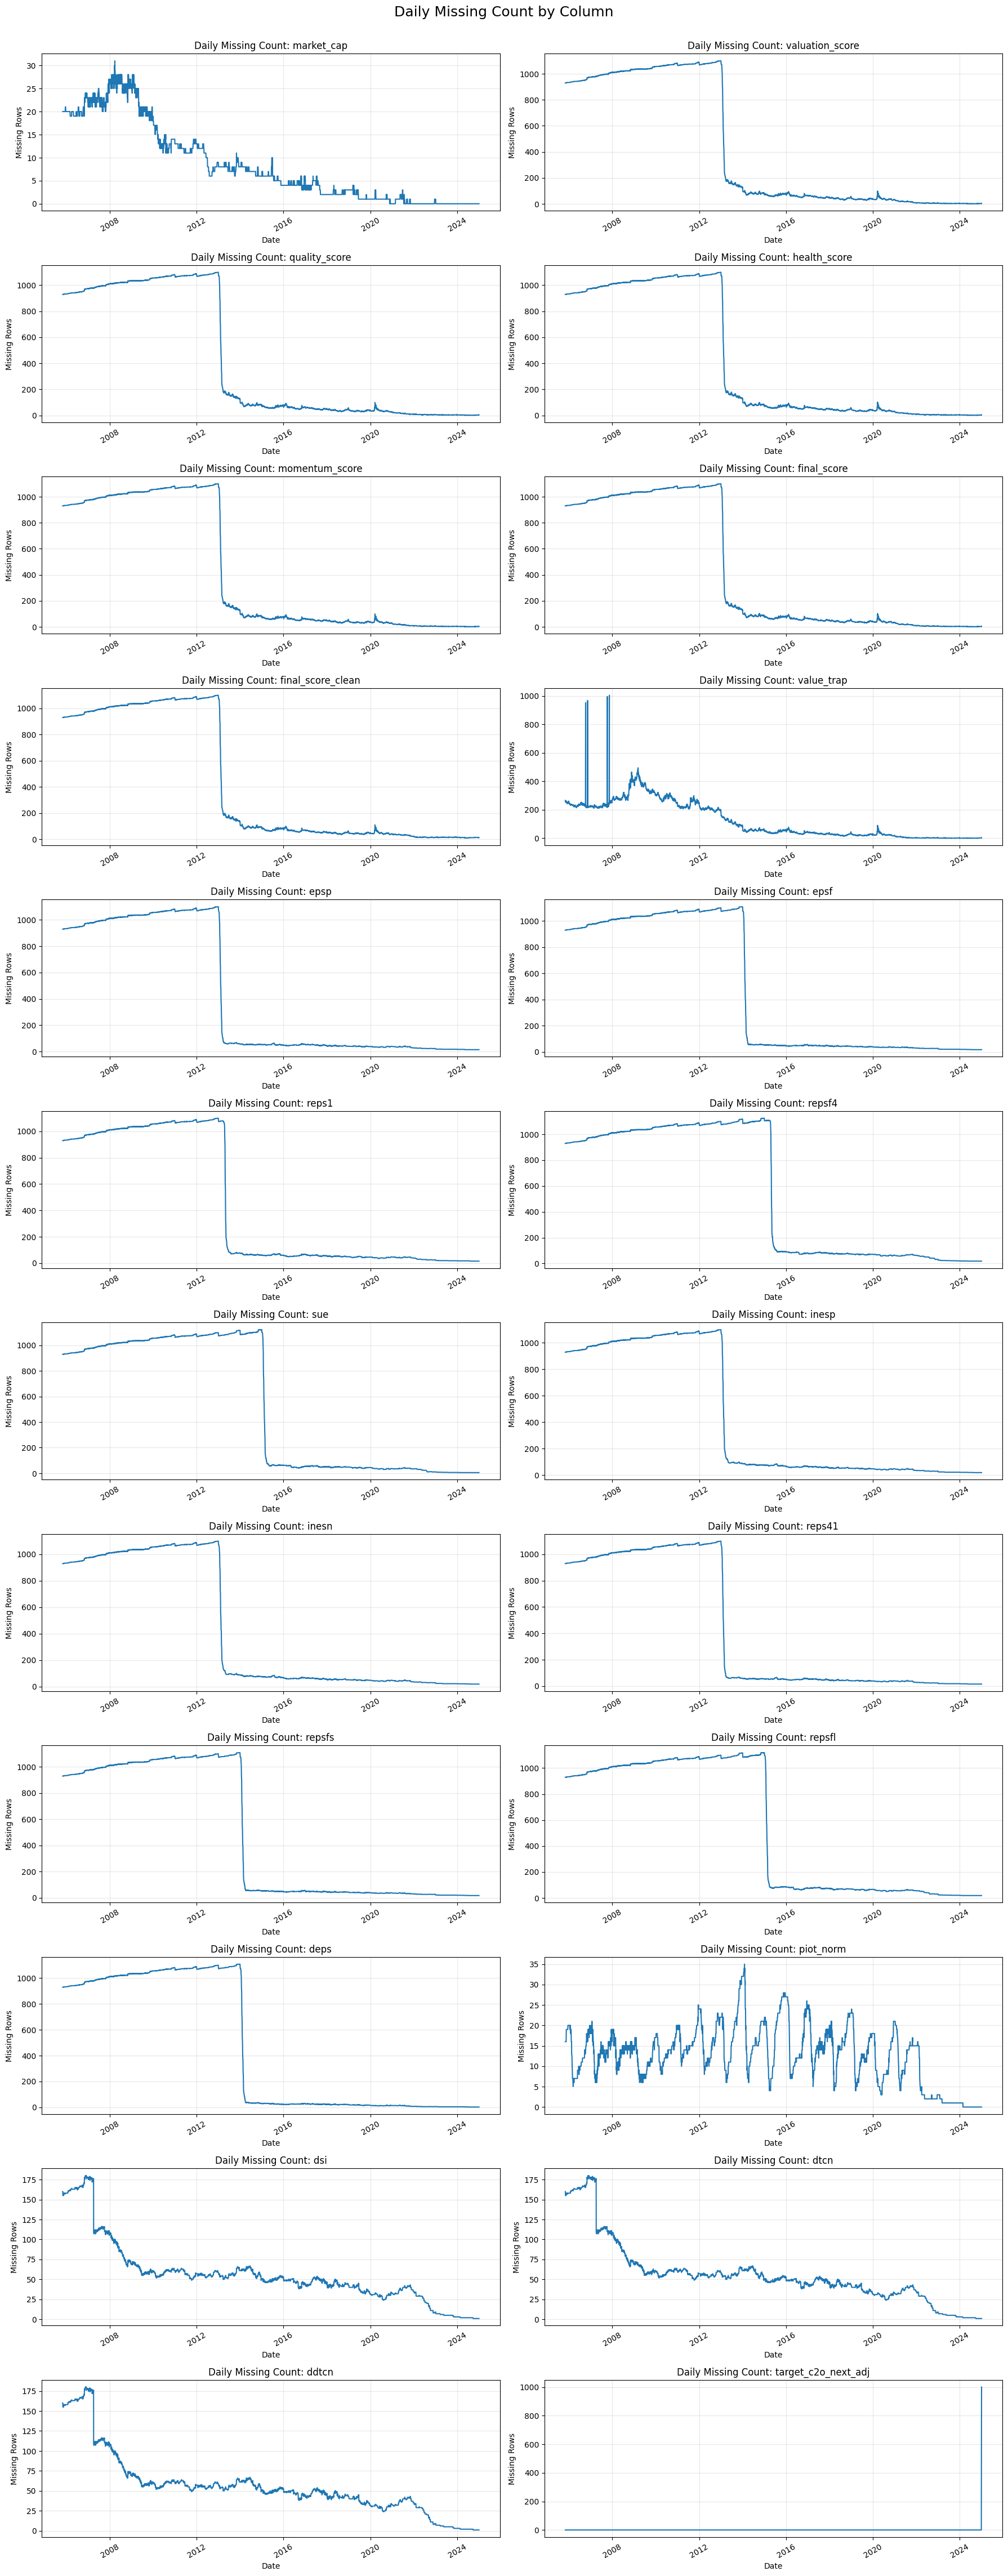

In [141]:
# Plot daily missing-value counts for every column with missing data.
import math
import pandas as pd
import matplotlib.pyplot as plt

na_cols = df_all.columns[df_all.isna().any()].tolist()

daily_missing = (
    df_all
    .groupby("date")[na_cols]
    .apply(lambda x: x.isna().sum())
    .reset_index()
)

n_cols = 2
n_rows = math.ceil(len(na_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 3.8 * n_rows),
    sharex=False   # Do not share the x-axis so each subplot shows its own dates.
)

axes = axes.flatten()

for i, col in enumerate(na_cols):
    ax = axes[i]
    
    ax.plot(daily_missing["date"], daily_missing[col])
    ax.set_title(f"Daily Missing Count: {col}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Missing Rows")
    ax.grid(True, alpha=0.3)
    
    # Rotate date labels to avoid crowding.
    ax.tick_params(axis="x", labelrotation=30)

# Turn off unused subplot axes.
for j in range(len(na_cols), len(axes)):
    axes[j].axis("off")

fig.suptitle(
    "Daily Missing Count by Column",
    fontsize=18,
    y=1.002
)

plt.tight_layout()
plt.show()

Define basic price-volume features such as returns, volatility, trading range, turnover-weighted return, volume z-score, and distance to recent highs or lows.

In [142]:
# Create basic return, volatility, turnover, range, and breakout features.
def basic_price_volume_features(df, ns = [1, 5, 21, 252]):   

    df = df.copy()
    
    for n in ns:
        df[f"return_{n}"] = (
            df.groupby("instrument_id")["close"]
            .pct_change(n)
        )
    

    df["overnight_return"] = (
        df.groupby("instrument_id")["open"].shift(-1)
        / df["close"]
        - 1
    )

    df["ret_std_20"] = (
        df.groupby("instrument_id")["return_1"]
        .transform(lambda x: x.rolling(20, min_periods=20).std())
    )

    df["on_ret_std_20"] = (
        df.groupby("instrument_id")["overnight_return"]
        .transform(lambda x: x.rolling(20, min_periods=20).std())
    )

    df["range_pct"] = (
        (df["high"] - df["low"]) / df["close"]
    )

    df["estimate_turnover"] = (
        (df["high"] + df["low"] + df["close"]) / 3
        * df["volume"]
    )

    df["twr_num"] = df["estimate_turnover"] * df["return_1"]

    df["twr_20"] = (
        df.groupby("instrument_id")["twr_num"]
        .transform(lambda x: x.rolling(20, min_periods=20).sum())
        /
        df.groupby("instrument_id")["estimate_turnover"]
        .transform(lambda x: x.rolling(20, min_periods=20).sum())
    )

    df["volume_z_20"] = (
        df.groupby("instrument_id")["volume"]
        .transform(
            lambda x: (
                (x - x.rolling(20, min_periods=20).mean())
                / x.rolling(20, min_periods=20).std()
            )
        )
    )

    df["high_20"] = (
        df.groupby("instrument_id")["high"]
        .transform(lambda x: x.rolling(20, min_periods=20).max())
    )

    df["low_20"] = (
        df.groupby("instrument_id")["low"]
        .transform(lambda x: x.rolling(20, min_periods=20).min())
    )

    df["dist_to_high_20"] = df["close"] / df["high_20"] - 1
    df["dist_to_low_20"] = df["close"] / df["low_20"] - 1

    df["channel_pos_20"] = (
        (df["close"] - df["low_20"])
        / (df["high_20"] - df["low_20"])
    )
    df = df.drop(columns=["twr_num", "high_20", "low_20"])
    df = df.replace([np.inf, -np.inf], np.nan)

    return df

Apply the basic price-volume feature function to the combined lookback panel.

In [143]:
# Apply the basic price-volume feature function.
df_all = basic_price_volume_features(df_all)

/var/folders/yb/8ggp9gv52cb8_8xlnpwq7qz40000gn/T/ipykernel_69621/4094622381.py:76: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace([np.inf, -np.inf], np.nan)


Define TA-Lib technical indicators for each stock and selected OHLCV input column.

In [144]:
# Create technical-analysis features with TA-Lib for each stock.
import talib

def add_talib_features(
    df,
    periods=[5, 20, 252],
    x_cols=[
        "open", "high", "low", "close", "volume",
    ],
    date_col="date",
    instrument_col="instrument_id"
):

    out = df.copy()

    out[date_col] = pd.to_datetime(out[date_col])
    out = out.sort_values([instrument_col, date_col]).reset_index(drop=True)

    x_cols = [c for c in x_cols if c in out.columns]

    feature_dfs = []

    for inst, g in out.groupby(instrument_col, sort=False):
        g = g.sort_values(date_col).copy()

        feat_dict = {}

        high = (
            g["high"]
            .astype(float)
            .replace([np.inf, -np.inf], np.nan)
            .to_numpy()
        )

        low = (
            g["low"]
            .astype(float)
            .replace([np.inf, -np.inf], np.nan)
            .to_numpy()
        )

        close = (
            g["close"]
            .astype(float)
            .replace([np.inf, -np.inf], np.nan)
            .to_numpy()
        )

        volume = (
            g["volume"]
            .astype(float)
            .replace([np.inf, -np.inf], np.nan)
            .to_numpy()
        )


        # X-based indicators
        for x_col in x_cols:
            x = (
                g[x_col]
                .astype(float)
                .replace([np.inf, -np.inf], np.nan)
                .to_numpy()
            )

            for d in periods:
                feat_dict[f"DEMA_{x_col}_{d}"] = talib.DEMA(x, timeperiod=d)
                feat_dict[f"KAMA_{x_col}_{d}"] = talib.KAMA(x, timeperiod=d)
                feat_dict[f"MIDPOINT_{x_col}_{d}"] = talib.MIDPOINT(x, timeperiod=d)
                feat_dict[f"LINEARREG_SLOPE_{x_col}_{d}"] = talib.LINEARREG_SLOPE(
                    x,
                    timeperiod=d
                )


            try:
                feat_dict[f"HT_DCPHASE_{x_col}"] = talib.HT_DCPHASE(x)
            except Exception:
                feat_dict[f"HT_DCPHASE_{x_col}"] = np.full(len(g), np.nan)

        # --------------------------------------------------------
        # OHLCV-based indicators
        # --------------------------------------------------------
        for d in periods:
            feat_dict[f"WILLR_{d}"] = talib.WILLR(
                high,
                low,
                close,
                timeperiod=d
            )

            feat_dict[f"CCI_{d}"] = talib.CCI(
                high,
                low,
                close,
                timeperiod=d
            )

            feat_dict[f"ADX_{d}"] = talib.ADX(
                high,
                low,
                close,
                timeperiod=d
            )

            feat_dict[f"NATR_{d}"] = talib.NATR(
                high,
                low,
                close,
                timeperiod=d
            )

        feat = pd.DataFrame(feat_dict, index=g.index)
        feature_dfs.append(feat)

    feature_df = pd.concat(feature_dfs, axis=0).sort_index()

    out = pd.concat([out, feature_df], axis=1)

    # de-fragment dataframe
    out = out.copy()

    return out

Apply TA-Lib technical feature generation to the full panel.

In [145]:
# Apply TA-Lib feature generation to the full feature panel.
df_featured = add_talib_features(df_all)


Plot the number of featured rows by date as a quick coverage check.

<Axes: xlabel='date'>

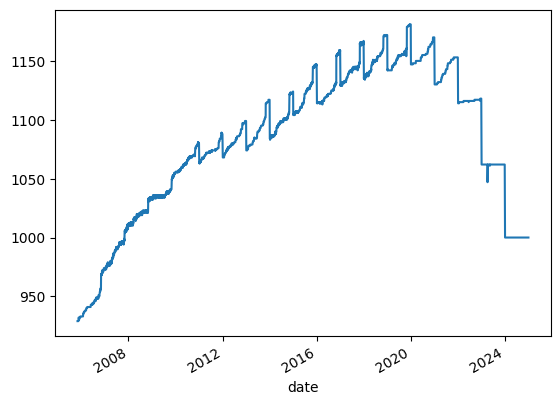

In [146]:
# Plot the number of featured rows by date.
df_featured.groupby('date').size().plot()

Save the final featured dataset after dropping rows without the target close-to-open return.

In [147]:
# Save the final featured dataset with valid target returns.
df_featured.dropna(subset='target_c2o_next_adj').to_parquet('data/df_featured.parquet')
